# Notebook 03 — Implementasi Model, Evaluasi, dan Pelabelan Dataset Akhir

**Deskripsi:**
Notebook ini terdiri atas **dua bagian utama**:

### BAGIAN I — Evaluasi Komparatif Model
Mengimplementasikan dan mengevaluasi **lima pendekatan model NLP** untuk
klasifikasi sentimen pada dataset ulasan *attraction* multibahasa di Bali.

| No | Model | Pendekatan | Checkpoint / Metode |
|----|-------|------------|---------------------|
| 1 | GPT *prompt-based zero-shot* | *Prompt-based* | Prediksi dari kolom `gpt_pred` |
| 2 | mBERT-XNLI *zero-shot* | *Zero-shot* (NLI) | `AyoubChLin/bert-base-multilingual-cased-xnli-nli` |
| 3 | XLM-RoBERTa *zero-shot* | *Zero-shot* (NLI) | `joeddav/xlm-roberta-large-xnli` |
| 4 | mBERT *fine-tuned* | *Fine-tuning* | `bert-base-multilingual-cased` |
| 5 | XLM-RoBERTa *fine-tuned* | *Fine-tuning* | `xlm-roberta-base` |

### BAGIAN II — Pelabelan Dataset Akhir
Menerapkan **model terbaik** hasil evaluasi untuk melakukan pelabelan sentimen
pada **keseluruhan dataset**, kemudian menyusun dataset akhir siap publikasi
sebagai luaran utama penelitian.

---

**Input:**
- `Train_Set.xlsx`, `Validation_Set.xlsx` (output Notebook 02)
- `Test_Set_Dengan_GPT_Label.xlsx` (test set yang sudah berisi kolom `gpt_pred`)
- `Dataset_Final_Preprocessed.xlsx` (dataset penuh, output Notebook 02)

**Output:**
- `Hasil_Evaluasi_Model.xlsx` — seluruh hasil evaluasi komparatif
- `Test_Set_Dengan_Prediksi_Semua_Model.xlsx` — test set + prediksi 5 model
- `Dataset_Ulasan_Attraction_Bali_Berlabel_Sentimen.csv` / `.xlsx` — **dataset akhir siap publikasi**
- Berkas visualisasi (`.png`) untuk confusion matrix, perbandingan model, dan distribusi label

**Catatan metodologis:**
Seluruh model dievaluasi menggunakan **test set yang sama** agar perbandingan
performa dapat dilakukan secara adil dan objektif. Metrik utama yang digunakan
adalah **macro F1-score** karena distribusi kelas pada dataset tidak seimbang.

---

# BAGIAN I — EVALUASI KOMPARATIF MODEL

## Section 1 — Persiapan Lingkungan dan Import Dependensi

In [ ]:
# Cek ketersediaan GPU
!nvidia-smi

Mon Aug 10 19:51:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q pandas openpyxl numpy matplotlib seaborn scikit-learn
!pip install -q transformers datasets accelerate sentencepiece safetensors

print("✅ Semua library berhasil diinstall!")

✅ Semua library berhasil diinstall!


In [ ]:
import os
import gc
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Catatan: pustaka `datasets` sengaja TIDAK digunakan untuk fine-tuning
# karena terdapat inkompatibilitas versi antara `datasets` dan
# `torchvision` terbaru. Sebagai gantinya digunakan kelas Dataset
# berbasis PyTorch yang didefinisikan pada Section 7.
from torch.utils.data import Dataset as TorchDataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    DataCollatorWithPadding
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("✅ Semua library berhasil diimport!")
print(f"   Device         : {device}")
print(f"   Torch version  : {torch.__version__}")
print(f"   CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU            : {torch.cuda.get_device_name(0)}")
print(f"   Random seed    : {SEED}")

✅ Semua library berhasil diimport!
   Device         : cuda
   Torch version  : 2.11.0+cu128
   CUDA available : True
   GPU            : Tesla T4
   Random seed    : 42


### 1.1 — Penyimpanan Persisten (Google Drive)

Google Colab menghapus seluruh berkas ketika sesi berakhir, termasuk model
hasil pelatihan. Untuk mencegah kehilangan hasil eksperimen, seluruh luaran
disimpan ke **Google Drive** sehingga tetap tersedia meskipun sesi terputus.

Dengan pengaturan ini, model yang telah dilatih tidak perlu dilatih ulang
apabila proses perlu dilanjutkan pada sesi berikutnya.

> Atur `USE_DRIVE = False` apabila notebook dijalankan di luar Google Colab.

In [ ]:
# Konfigurasi penyimpanan persisten
USE_DRIVE = True   # True → simpan hasil ke Google Drive (disarankan di Colab)

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        OUTPUT_BASE = '/content/drive/MyDrive/Skripsi_NLP_Attraction'
        os.makedirs(OUTPUT_BASE, exist_ok=True)
        print(f"✅ Google Drive terhubung.")
        print(f"   Direktori luaran: {OUTPUT_BASE}")
    except Exception as e:
        print(f"⚠️  Gagal menghubungkan Google Drive: {e}")
        print(f"   Luaran akan disimpan pada penyimpanan sementara.")
        OUTPUT_BASE = '.'
else:
    OUTPUT_BASE = '.'
    print(f"ℹ️  Penyimpanan lokal digunakan: {OUTPUT_BASE}")

# Direktori khusus untuk menyimpan model hasil pelatihan
MODEL_BASE = os.path.join(OUTPUT_BASE, 'model')
os.makedirs(MODEL_BASE, exist_ok=True)

print(f"\n📁 Struktur penyimpanan:")
print(f"   Luaran umum : {OUTPUT_BASE}")
print(f"   Model       : {MODEL_BASE}")

if OUTPUT_BASE != '.':
    print(f"\n💡 Model hasil pelatihan akan tetap tersimpan meskipun sesi Colab")
    print(f"   berakhir, sehingga tidak perlu dilatih ulang pada sesi berikutnya.")

Mounted at /content/drive
✅ Google Drive terhubung.
   Direktori luaran: /content/drive/MyDrive/Skripsi_NLP_Attraction

📁 Struktur penyimpanan:
   Luaran umum : /content/drive/MyDrive/Skripsi_NLP_Attraction
   Model       : /content/drive/MyDrive/Skripsi_NLP_Attraction/model

💡 Model hasil pelatihan akan tetap tersimpan meskipun sesi Colab
   berakhir, sehingga tidak perlu dilatih ulang pada sesi berikutnya.


## Section 2 — Konfigurasi Global dan Registry Model

Seluruh konfigurasi eksperimen dan definisi model dipusatkan pada satu tempat
agar konsisten di seluruh notebook dan menghindari ketidaksesuaian penamaan
kolom prediksi antar tahapan.

In [ ]:
# Konfigurasi label
LABEL_ORDER = ["negatif", "netral", "positif"]

label2id = {"negatif": 0, "netral": 1, "positif": 2}
id2label = {0: "negatif", 1: "netral", 2: "positif"}

# Konfigurasi hyperparameter fine-tuning
MAX_LENGTH        = 128
NUM_EPOCHS        = 3
LEARNING_RATE     = 2e-5
TRAIN_BATCH_SIZE  = 16
EVAL_BATCH_SIZE   = 32

# Konfigurasi zero-shot
CANDIDATE_LABELS    = ["positive", "neutral", "negative"]
HYPOTHESIS_TEMPLATE = "This tourism review is {}."

LABEL_EN_TO_ID = {
    "positive": "positif",
    "neutral" : "netral",
    "negative": "negatif",
}

# Checkpoint model
MBERT_ZERO_SHOT_CKPT = "AyoubChLin/bert-base-multilingual-cased-xnli-nli"
XLMR_ZERO_SHOT_CKPT  = "joeddav/xlm-roberta-large-xnli"
MBERT_FINETUNE_CKPT  = "bert-base-multilingual-cased"
XLMR_FINETUNE_CKPT   = "xlm-roberta-base"

print("✅ Konfigurasi global berhasil dimuat.")
print(f"   Label order   : {LABEL_ORDER}")
print(f"   Max length    : {MAX_LENGTH}")
print(f"   Epochs        : {NUM_EPOCHS}")
print(f"   Learning rate : {LEARNING_RATE}")

✅ Konfigurasi global berhasil dimuat.
   Label order   : ['negatif', 'netral', 'positif']
   Max length    : 128
   Epochs        : 3
   Learning rate : 2e-05


In [ ]:
# REGISTRY MODEL
# Sumber tunggal kebenaran (single source of truth) untuk nama model dan
# nama kolom prediksinya. Seluruh tahapan evaluasi merujuk ke registry ini
# agar tidak terjadi ketidaksesuaian penamaan antar tahapan.

MODEL_REGISTRY = [
    {
        "label"    : "GPT prompt-based zero-shot",
        "pred_col" : "gpt_pred",
        "score_col": None,
        "approach" : "Prompt-based zero-shot",
        "checkpoint": "Prediksi dari kolom gpt_pred",
    },
    {
        "label"    : "mBERT-XNLI zero-shot",
        "pred_col" : "mbert_xnli_zero_shot_pred",
        "score_col": "mbert_xnli_zero_shot_score",
        "approach" : "Zero-shot (NLI)",
        "checkpoint": MBERT_ZERO_SHOT_CKPT,
    },
    {
        "label"    : "XLM-RoBERTa zero-shot",
        "pred_col" : "xlm_roberta_zero_shot_pred",
        "score_col": "xlm_roberta_zero_shot_score",
        "approach" : "Zero-shot (NLI)",
        "checkpoint": XLMR_ZERO_SHOT_CKPT,
    },
    {
        "label"    : "mBERT fine-tuned",
        "pred_col" : "mbert_finetuned_pred",
        "score_col": None,
        "approach" : "Fine-tuning",
        "checkpoint": MBERT_FINETUNE_CKPT,
    },
    {
        "label"    : "XLM-RoBERTa fine-tuned",
        "pred_col" : "xlm_roberta_finetuned_pred",
        "score_col": None,
        "approach" : "Fine-tuning",
        "checkpoint": XLMR_FINETUNE_CKPT,
    },
]

# Tampilkan sebagai tabel skenario evaluasi
skenario_df = pd.DataFrame([
    {
        "No"           : i + 1,
        "Model"        : m["label"],
        "Pendekatan"   : m["approach"],
        "Checkpoint"   : m["checkpoint"],
        "Kolom Prediksi": m["pred_col"],
    }
    for i, m in enumerate(MODEL_REGISTRY)
])

print("📋 SKENARIO EVALUASI MODEL")
display(skenario_df)

📋 SKENARIO EVALUASI MODEL


,No,Model,Pendekatan,Checkpoint,Kolom Prediksi
0,1,GPT prompt-based zero-shot,Prompt-based zero-shot,Prediksi dari kolom gpt_pred,gpt_pred
1,2,mBERT-XNLI zero-shot,Zero-shot (NLI),AyoubChLin/bert-base-multilingual-cased-xnli-nli,mbert_xnli_zero_shot_pred
2,3,XLM-RoBERTa zero-shot,Zero-shot (NLI),joeddav/xlm-roberta-large-xnli,xlm_roberta_zero_shot_pred
3,4,mBERT fine-tuned,Fine-tuning,bert-base-multilingual-cased,mbert_finetuned_pred
4,5,XLM-RoBERTa fine-tuned,Fine-tuning,xlm-roberta-base,xlm_roberta_finetuned_pred


## Section 3 — Pembacaan dan Validasi Dataset

Pembacaan tiga subset hasil Notebook 02. Test set yang digunakan adalah
versi yang sudah dilengkapi kolom `gpt_pred`, yaitu hasil pelabelan
GPT *prompt-based zero-shot* yang dilakukan sebelumnya.

In [ ]:
TRAIN_FILE = "Train_Set .xlsx"
VAL_FILE   = "Validation_Set .xlsx"
TEST_FILE  = "Test_Set_Dengan_GPT_Label.xlsx"   # test set + kolom gpt_pred


def read_file(filename):
    """Membaca file Excel atau CSV."""
    if filename.endswith(".xlsx"):
        return pd.read_excel(filename)
    elif filename.endswith(".csv"):
        return pd.read_csv(filename)
    else:
        raise ValueError(f"Format file tidak didukung: {filename}")


train_df = read_file(TRAIN_FILE)
val_df   = read_file(VAL_FILE)
test_df  = read_file(TEST_FILE)

print("✅ Dataset berhasil dibaca")
print(f"   Train      : {train_df.shape[0]:,} baris × {train_df.shape[1]} kolom")
print(f"   Validation : {val_df.shape[0]:,} baris × {val_df.shape[1]} kolom")
print(f"   Test       : {test_df.shape[0]:,} baris × {test_df.shape[1]} kolom")

print(f"\n📋 Kolom test set:")
print(f"   {test_df.columns.tolist()}")

✅ Dataset berhasil dibaca
   Train      : 7,543 baris × 13 kolom
   Validation : 1,617 baris × 13 kolom
   Test       : 1,617 baris × 14 kolom

📋 Kolom test set:
   ['review_id', 'user_id', 'nama_tempat', 'id_tempat', 'rating', 'kabupaten', 'provinsi', 'review', 'language', 'language_original', 'proxy_sentiment', 'sumber', 'review_clean', 'gpt_pred']


In [ ]:
# Tentukan kolom teks yang digunakan sebagai input model
if "review_clean" in test_df.columns:
    TEXT_COL = "review_clean"
elif "review" in test_df.columns:
    TEXT_COL = "review"
else:
    raise ValueError("❌ Tidak ditemukan kolom review_clean atau review.")

print(f"✅ Kolom teks input model: '{TEXT_COL}'")

# Pastikan review_id tersedia pada setiap subset
for df_name, df_ in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    if "review_id" not in df_.columns:
        print(f"   ⚠️  {df_name} belum punya review_id, dibuat otomatis.")
        df_.reset_index(drop=True, inplace=True)
        df_.insert(0, "review_id", range(1, len(df_) + 1))

# Verifikasi kolom gpt_pred tersedia
if "gpt_pred" in test_df.columns:
    print(f"✅ Kolom 'gpt_pred' tersedia — GPT akan dievaluasi.")
else:
    print(f"⚠️  Kolom 'gpt_pred' TIDAK ditemukan — GPT tidak akan dievaluasi.")

test_df[["review_id", TEXT_COL]].head(3)

✅ Kolom teks input model: 'review_clean'
✅ Kolom 'gpt_pred' tersedia — GPT akan dievaluasi.


,review_id,review_clean
0,350,Seru banget...
1,4779,Air terjun yang sangat Indah.
2,1157,Saya nyaman di tempat ini


### 3.1 — Pemeriksaan Awal Sebelum Eksperimen (*Pre-Flight Check*)

Sel berikut memverifikasi seluruh prasyarat eksperimen **sebelum** proses
yang membutuhkan GPU dijalankan. Tujuannya adalah memastikan tidak terjadi
kegagalan di tengah proses pelatihan yang memakan waktu lama.

Pemeriksaan meliputi ketersediaan berkas masukan, kelengkapan kolom,
ketersediaan GPU, serta kompatibilitas versi pustaka.

In [ ]:
# PRE-FLIGHT CHECK: verifikasi prasyarat sebelum eksperimen
import importlib.metadata as _md

print("=" * 65)
print("PEMERIKSAAN AWAL SEBELUM EKSPERIMEN")
print("=" * 65)

_lolos = True

# 1. Versi pustaka utama
print("\n[1] Versi pustaka:")
for _pkg in ["transformers", "torch", "scikit-learn", "pandas", "accelerate"]:
    try:
        print(f"    ✅ {_pkg:<15}: {_md.version(_pkg)}")
    except Exception:
        print(f"    ⚠️  {_pkg:<15}: tidak terdeteksi")

# 2. Ketersediaan GPU
print("\n[2] Perangkat komputasi:")
if torch.cuda.is_available():
    _mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"    ✅ GPU tersedia : {torch.cuda.get_device_name(0)} ({_mem:.1f} GB)")
else:
    print(f"    ⚠️  GPU TIDAK tersedia — proses akan sangat lambat.")
    print(f"       Aktifkan melalui: Runtime → Change runtime type → T4 GPU")
    _lolos = False

# 3. Berkas masukan
print("\n[3] Ketersediaan berkas masukan:")
for _f in [TRAIN_FILE, VAL_FILE, TEST_FILE, "Dataset_Final_Preprocessed.xlsx"]:
    if os.path.exists(_f):
        _size = os.path.getsize(_f) / 1024**2
        print(f"    ✅ {_f:<38} ({_size:.1f} MB)")
    else:
        print(f"    ❌ {_f:<38} TIDAK DITEMUKAN")
        _lolos = False

# 4. Kelengkapan kolom pada test set
print("\n[4] Kelengkapan kolom test set:")
_wajib = ["review_id", "proxy_sentiment", "language", TEXT_COL, "gpt_pred"]
for _col in _wajib:
    if _col in test_df.columns:
        print(f"    ✅ {_col}")
    else:
        print(f"    ❌ {_col} TIDAK ADA")
        _lolos = False

# 5. Konsistensi jumlah data
print("\n[5] Konsistensi data:")
print(f"    Train / Validation / Test : "
      f"{len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"    Distribusi label test set : "
      f"{dict(test_df['proxy_sentiment'].value_counts())}")

# 6. Ruang penyimpanan
print("\n[6] Ruang penyimpanan:")
try:
    _st = os.statvfs(".")
    _free = _st.f_bavail * _st.f_frsize / 1024**3
    if _free < 5:
        print(f"    ⚠️  Sisa ruang: {_free:.1f} GB — mungkin tidak cukup")
    else:
        print(f"    ✅ Sisa ruang: {_free:.1f} GB")
except Exception:
    print(f"    ℹ️  Tidak dapat memeriksa ruang penyimpanan")

print("\n" + "=" * 65)
if _lolos:
    print("✅ SELURUH PEMERIKSAAN LOLOS — eksperimen siap dijalankan.")
else:
    print("❌ ADA PEMERIKSAAN YANG GAGAL — perbaiki terlebih dahulu")
    print("   sebelum melanjutkan agar kuota GPU tidak terbuang.")
print("=" * 65)

PEMERIKSAAN AWAL SEBELUM EKSPERIMEN

[1] Versi pustaka:
    ✅ transformers   : 5.13.1
    ✅ torch          : 2.11.0+cu128
    ✅ scikit-learn   : 1.6.1
    ✅ pandas         : 2.2.2
    ✅ accelerate     : 1.14.0

[2] Perangkat komputasi:
    ✅ GPU tersedia : Tesla T4 (14.6 GB)

[3] Ketersediaan berkas masukan:
    ✅ Train_Set .xlsx                        (1.9 MB)
    ✅ Validation_Set .xlsx                   (0.4 MB)
    ✅ Test_Set_Dengan_GPT_Label.xlsx         (0.4 MB)
    ✅ Dataset_Final_Preprocessed.xlsx        (2.3 MB)

[4] Kelengkapan kolom test set:
    ✅ review_id
    ✅ proxy_sentiment
    ✅ language
    ✅ review_clean
    ✅ gpt_pred

[5] Konsistensi data:
    Train / Validation / Test : 7,543 / 1,617 / 1,617
    Distribusi label test set : {'positif': np.int64(1307), 'negatif': np.int64(201), 'netral': np.int64(109)}

[6] Ruang penyimpanan:
    ✅ Sisa ruang: 65.9 GB

✅ SELURUH PEMERIKSAAN LOLOS — eksperimen siap dijalankan.


## Section 4 — Normalisasi Label dan Fungsi Evaluasi

Sebelum evaluasi dilakukan, seluruh label (baik label acuan maupun hasil
prediksi model) dinormalisasi ke dalam tiga kelas standar: **negatif**,
**netral**, dan **positif**.

Normalisasi diperlukan karena model dapat menghasilkan variasi penulisan label
seperti `positive`, `Positif`, `POSITIF`, atau label yang mengandung tanda baca.

In [ ]:
# Fungsi normalisasi label
def normalize_label(label):
    """
    Menormalisasi variasi penulisan label ke tiga kelas standar:
    negatif, netral, positif. Mengembalikan 'unknown' jika tidak dikenali.
    """
    label = str(label).strip().lower()

    # Bersihkan tanda baca yang mungkin ikut terbawa
    for ch in [".", ",", ";", "`", '"', "'", "!", "?", ":"]:
        label = label.replace(ch, "")

    label = label.strip()

    if "positive" in label or "positif" in label:
        return "positif"
    elif "neutral" in label or "netral" in label:
        return "netral"
    elif "negative" in label or "negatif" in label:
        return "negatif"
    else:
        return "unknown"


# Terapkan normalisasi pada label acuan (proxy_sentiment)
for df_ in [train_df, val_df, test_df]:
    df_["proxy_sentiment"] = df_["proxy_sentiment"].apply(normalize_label)

# Terapkan normalisasi pada prediksi GPT
if "gpt_pred" in test_df.columns:
    test_df["gpt_pred"] = test_df["gpt_pred"].apply(normalize_label)

print("✅ Normalisasi label selesai")
print(f"\n📊 Distribusi proxy_sentiment pada test set:")
print(test_df["proxy_sentiment"].value_counts())

if "gpt_pred" in test_df.columns:
    print(f"\n📊 Distribusi prediksi GPT:")
    print(test_df["gpt_pred"].value_counts())

✅ Normalisasi label selesai

📊 Distribusi proxy_sentiment pada test set:
proxy_sentiment
positif    1307
negatif     201
netral      109
Name: count, dtype: int64

📊 Distribusi prediksi GPT:
gpt_pred
positif    1117
netral      275
negatif     225
Name: count, dtype: int64


In [ ]:
# Filter data yang valid untuk evaluasi
n_before = {"train": len(train_df), "val": len(val_df), "test": len(test_df)}

# Hanya pertahankan baris dengan label acuan valid
train_df = train_df[train_df["proxy_sentiment"].isin(LABEL_ORDER)].copy()
val_df   = val_df[val_df["proxy_sentiment"].isin(LABEL_ORDER)].copy()
test_df  = test_df[test_df["proxy_sentiment"].isin(LABEL_ORDER)].copy()

# Hanya pertahankan teks dengan panjang memadai
train_df = train_df[train_df[TEXT_COL].astype(str).str.len() >= 10].copy()
val_df   = val_df[val_df[TEXT_COL].astype(str).str.len() >= 10].copy()
test_df  = test_df[test_df[TEXT_COL].astype(str).str.len() >= 10].copy()

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("✅ Filtering data valid selesai")
print(f"   Train      : {n_before['train']:,} → {len(train_df):,}")
print(f"   Validation : {n_before['val']:,} → {len(val_df):,}")
print(f"   Test       : {n_before['test']:,} → {len(test_df):,}")

✅ Filtering data valid selesai
   Train      : 7,543 → 7,543
   Validation : 1,617 → 1,617
   Test       : 1,617 → 1,617


In [ ]:
# Fungsi evaluasi utama
def evaluate_predictions(y_true, y_pred, model_name):
    """
    Menghitung metrik evaluasi lengkap untuk satu model.

    Returns:
        result (dict)  : ringkasan metrik utama
        report (dict)  : classification report per kelas
        cm (ndarray)   : confusion matrix
    """
    y_true = [normalize_label(x) for x in y_true]
    y_pred = [normalize_label(x) for x in y_pred]

    # Hanya evaluasi baris yang label acuan dan prediksinya valid
    valid_idx = [
        i for i, pred in enumerate(y_pred)
        if pred in LABEL_ORDER and y_true[i] in LABEL_ORDER
    ]

    y_true_valid = [y_true[i] for i in valid_idx]
    y_pred_valid = [y_pred[i] for i in valid_idx]

    acc = accuracy_score(y_true_valid, y_pred_valid)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true_valid, y_pred_valid,
        labels=LABEL_ORDER, average="macro", zero_division=0
    )

    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true_valid, y_pred_valid,
        labels=LABEL_ORDER, average="weighted", zero_division=0
    )

    report = classification_report(
        y_true_valid, y_pred_valid,
        labels=LABEL_ORDER, zero_division=0, output_dict=True
    )

    cm = confusion_matrix(y_true_valid, y_pred_valid, labels=LABEL_ORDER)

    result = {
        "model"              : model_name,
        "n_data"             : len(y_true_valid),
        "accuracy"           : acc,
        "macro_precision"    : p_macro,
        "macro_recall"       : r_macro,
        "macro_f1"           : f1_macro,
        "weighted_precision" : p_weighted,
        "weighted_recall"    : r_weighted,
        "weighted_f1"        : f1_weighted,
    }

    return result, report, cm


print("✅ Fungsi evaluate_predictions() siap digunakan.")

✅ Fungsi evaluate_predictions() siap digunakan.


In [ ]:
# Fungsi visualisasi confusion matrix
def show_confusion_matrix(cm, title, save_as=None):
    """Menampilkan dan (opsional) menyimpan confusion matrix."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
        cmap="Blues", cbar=True
    )
    plt.xlabel("Predicted Label", fontweight="bold")
    plt.ylabel("True Label", fontweight="bold")
    plt.title(title, fontweight="bold")
    plt.tight_layout()

    if save_as:
        plt.savefig(save_as, dpi=300, bbox_inches="tight")
        print(f"   💾 Confusion matrix disimpan: {save_as}")

    plt.show()


def format_report(report):
    """Mengubah classification report menjadi DataFrame persen yang rapi."""
    rows = []
    for kelas in LABEL_ORDER:
        rows.append({
            "Kelas"     : kelas,
            "Precision" : round(report[kelas]["precision"] * 100, 2),
            "Recall"    : round(report[kelas]["recall"] * 100, 2),
            "F1-score"  : round(report[kelas]["f1-score"] * 100, 2),
            "Support"   : int(report[kelas]["support"]),
        })
    return pd.DataFrame(rows)


print("✅ Fungsi visualisasi dan formatting siap digunakan.")

✅ Fungsi visualisasi dan formatting siap digunakan.


In [ ]:
# Wadah penampung hasil evaluasi seluruh model
results       = []   # ringkasan metrik utama tiap model
reports       = {}   # classification report tiap model
conf_matrices = {}   # confusion matrix tiap model

# Mekanisme penyimpanan progres
# Google Colab dapat memutus sesi sewaktu-waktu. Fungsi berikut menyimpan
# hasil sementara ke berkas agar tidak perlu mengulang seluruh proses
# apabila sesi terputus di tengah eksperimen.

PROGRESS_FILE = os.path.join(OUTPUT_BASE, "progress_evaluasi.pkl")
PROGRESS_TESTDF = os.path.join(OUTPUT_BASE, "progress_test_df.pkl")


def simpan_progres():
    """Menyimpan hasil evaluasi sementara beserta prediksi model."""
    import pickle
    with open(PROGRESS_FILE, "wb") as f:
        pickle.dump({
            "results"       : results,
            "reports"       : reports,
            "conf_matrices" : conf_matrices,
        }, f)
    test_df.to_pickle(PROGRESS_TESTDF)
    print(f"   💾 Progres disimpan ({len(results)} model selesai)")


def muat_progres():
    """Memuat kembali hasil evaluasi yang tersimpan sebelumnya."""
    import pickle
    global results, reports, conf_matrices, test_df

    if not os.path.exists(PROGRESS_FILE):
        print("ℹ️  Belum ada progres tersimpan — mulai dari awal.")
        return False

    with open(PROGRESS_FILE, "rb") as f:
        data = pickle.load(f)

    results       = data["results"]
    reports       = data["reports"]
    conf_matrices = data["conf_matrices"]

    if os.path.exists(PROGRESS_TESTDF):
        test_df = pd.read_pickle(PROGRESS_TESTDF)

    print(f"✅ Progres dimuat — {len(results)} model sudah dievaluasi:")
    for r in results:
        print(f"      - {r['model']}")
    return True


print("✅ Wadah penampung hasil evaluasi disiapkan.")
print("\n💡 Jika sesi Colab terputus di tengah eksperimen, jalankan")
print("   `muat_progres()` untuk melanjutkan tanpa mengulang dari awal.")

✅ Wadah penampung hasil evaluasi disiapkan.

💡 Jika sesi Colab terputus di tengah eksperimen, jalankan
   `muat_progres()` untuk melanjutkan tanpa mengulang dari awal.


## Section 5 — Evaluasi Model 1: GPT *Prompt-Based Zero-Shot*

GPT dievaluasi menggunakan pendekatan *prompt-based zero-shot*, yaitu model
diberi instruksi berbahasa alami untuk menentukan sentimen sebuah ulasan
**tanpa pelatihan apa pun** pada data penelitian.

*Prompt* dirancang tertutup agar keluaran model terkendali — model diminta
menjawab hanya dengan salah satu dari tiga label.

Proses pelabelan oleh GPT dilakukan **sebelum notebook ini dijalankan**, dan
hasilnya tersimpan pada kolom `gpt_pred` dalam berkas test set.

In [ ]:
# Prompt yang digunakan pada proses pelabelan GPT
GPT_PROMPT_TEMPLATE = """Klasifikasikan sentimen ulasan wisata berikut ke dalam salah satu label: positif, netral, atau negatif.
Ulasan:
"{review_text}"
Jawab hanya dengan salah satu label: positif, netral, atau negatif."""

print("📝 Prompt yang digunakan pada pelabelan GPT:")
print("-" * 70)
print(GPT_PROMPT_TEMPLATE)
print("-" * 70)

📝 Prompt yang digunakan pada pelabelan GPT:
----------------------------------------------------------------------
Klasifikasikan sentimen ulasan wisata berikut ke dalam salah satu label: positif, netral, atau negatif.
Ulasan:
"{review_text}"
Jawab hanya dengan salah satu label: positif, netral, atau negatif.
----------------------------------------------------------------------


===== Evaluasi GPT prompt-based zero-shot =====

📊 Hasil Evaluasi:


,Nilai
Accuracy,83.67%
Macro Precision,68.36%
Macro Recall,79.39%
Macro F1-score,70.88%
Weighted F1-score,86.55%



📊 Classification Report per Kelas:


,Kelas,Precision,Recall,F1-score,Support
0,negatif,81.78,91.54,86.38,201
1,netral,24.73,62.39,35.42,109
2,positif,98.57,84.24,90.84,1307


   💾 Confusion matrix disimpan: cm_gpt_prompt_based_zero_shot.png


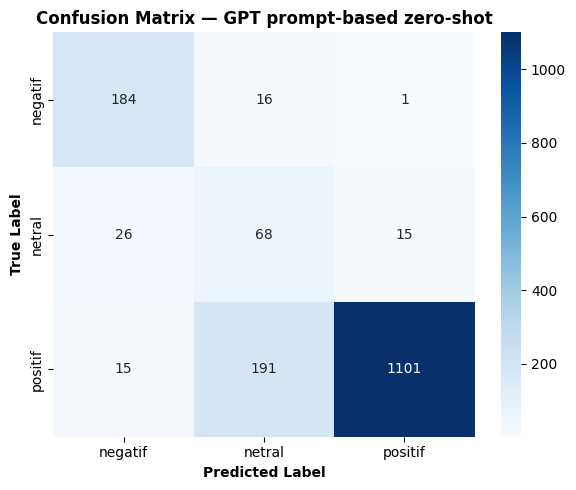

   💾 Progres disimpan (1 model selesai)


In [ ]:
# Evaluasi GPT prompt-based zero-shot
MODEL_LABEL = "GPT prompt-based zero-shot"
PRED_COL    = "gpt_pred"

if PRED_COL in test_df.columns:
    print(f"===== Evaluasi {MODEL_LABEL} =====\n")

    gpt_result, gpt_report, gpt_cm = evaluate_predictions(
        test_df["proxy_sentiment"],
        test_df[PRED_COL],
        model_name=MODEL_LABEL
    )

    results.append(gpt_result)
    reports[MODEL_LABEL] = gpt_report
    conf_matrices[MODEL_LABEL] = gpt_cm

    # Tampilkan metrik utama
    metrik_df = pd.DataFrame([{
        "Accuracy"          : f"{gpt_result['accuracy']*100:.2f}%",
        "Macro Precision"   : f"{gpt_result['macro_precision']*100:.2f}%",
        "Macro Recall"      : f"{gpt_result['macro_recall']*100:.2f}%",
        "Macro F1-score"    : f"{gpt_result['macro_f1']*100:.2f}%",
        "Weighted F1-score" : f"{gpt_result['weighted_f1']*100:.2f}%",
    }])
    print("📊 Hasil Evaluasi:")
    display(metrik_df.T.rename(columns={0: "Nilai"}))

    print("\n📊 Classification Report per Kelas:")
    display(format_report(gpt_report))

    show_confusion_matrix(
        gpt_cm,
        f"Confusion Matrix — {MODEL_LABEL}",
        save_as="cm_gpt_prompt_based_zero_shot.png"
    )

    simpan_progres()
else:
    print(f"⚠️  Kolom '{PRED_COL}' tidak ditemukan. {MODEL_LABEL} dilewati.")

## Section 6 — Evaluasi Model 2 & 3: Zero-Shot Berbasis NLI

Pendekatan *zero-shot classification* memanfaatkan model yang telah dilatih
pada tugas *Natural Language Inference* (NLI). Teks ulasan berperan sebagai
**premise**, sedangkan label sentimen dinyatakan sebagai **hypothesis** melalui
*hypothesis template*.

Model menghitung skor *entailment* untuk setiap kandidat label, kemudian label
dengan skor tertinggi dipilih sebagai hasil prediksi. Karena keluaran model
masih berbahasa Inggris, hasilnya dipetakan ke label Bahasa Indonesia sebelum
dievaluasi.

- **Candidate labels:** `positive`, `neutral`, `negative`
- **Hypothesis template:** `This tourism review is {}.`

In [ ]:
# Fungsi generik untuk menjalankan model zero-shot
def run_zero_shot_model(checkpoint, model_label, pred_col, score_col, batch_size=8):
    """
    Menjalankan inferensi zero-shot classification pada test set,
    lalu mengevaluasi hasilnya terhadap proxy_sentiment.
    """
    print(f"\n===== {model_label} =====")
    print(f"Checkpoint: {checkpoint}")
    print(f"⏳ Memuat model...")

    start_load = time.time()
    classifier = pipeline(
        "zero-shot-classification",
        model=checkpoint,
        tokenizer=checkpoint,
        device=0 if torch.cuda.is_available() else -1
    )
    print(f"✅ Model dimuat dalam {(time.time() - start_load)/60:.2f} menit.")

    texts  = test_df[TEXT_COL].astype(str).tolist()
    preds  = []
    scores = []

    print(f"⏳ Menjalankan inferensi pada {len(texts):,} ulasan...")
    start_time = time.time()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        try:
            batch_results = classifier(
                batch_texts,
                candidate_labels=CANDIDATE_LABELS,
                hypothesis_template=HYPOTHESIS_TEMPLATE,
                truncation=True
            )

            if isinstance(batch_results, dict):
                batch_results = [batch_results]

            for result in batch_results:
                preds.append(LABEL_EN_TO_ID[result["labels"][0]])
                scores.append(result["scores"][0])

        except Exception as e:
            print(f"   ⚠️  Error pada batch {start}: {e}")
            for _ in batch_texts:
                preds.append("unknown")
                scores.append(0.0)

        processed = min(start + batch_size, len(texts))
        if processed % 200 == 0 or processed == len(texts):
            print(f"   Progress: {processed:,}/{len(texts):,}", end="\r")

    elapsed = time.time() - start_time
    print(f"\n✅ Inferensi selesai dalam {elapsed/60:.2f} menit.")

    # Simpan hasil prediksi ke test_df
    test_df[pred_col]  = preds
    test_df[score_col] = scores

    # Evaluasi
    result, report, cm = evaluate_predictions(
        test_df["proxy_sentiment"],
        test_df[pred_col],
        model_name=model_label
    )

    results.append(result)
    reports[model_label] = report
    conf_matrices[model_label] = cm

    metrik_df = pd.DataFrame([{
        "Accuracy"          : f"{result['accuracy']*100:.2f}%",
        "Macro Precision"   : f"{result['macro_precision']*100:.2f}%",
        "Macro Recall"      : f"{result['macro_recall']*100:.2f}%",
        "Macro F1-score"    : f"{result['macro_f1']*100:.2f}%",
        "Weighted F1-score" : f"{result['weighted_f1']*100:.2f}%",
    }])
    print("\n📊 Hasil Evaluasi:")
    display(metrik_df.T.rename(columns={0: "Nilai"}))

    print("\n📊 Classification Report per Kelas:")
    display(format_report(report))

    safe_name = model_label.lower().replace(" ", "_").replace("-", "_")
    show_confusion_matrix(cm, f"Confusion Matrix — {model_label}",
                          save_as=f"cm_{safe_name}.png")

    # Simpan progres agar aman dari pemutusan sesi
    simpan_progres()

    # Bersihkan memori GPU
    del classifier
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


print("✅ Fungsi run_zero_shot_model() siap digunakan.")

✅ Fungsi run_zero_shot_model() siap digunakan.


### 6.1 — mBERT-XNLI Zero-Shot


===== mBERT-XNLI zero-shot =====
Checkpoint: AyoubChLin/bert-base-multilingual-cased-xnli-nli
⏳ Memuat model...


config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  711MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

   Progress: 1,617/1,617
✅ Inferensi selesai dalam 0.84 menit.

📊 Hasil Evaluasi:


,Nilai
Accuracy,79.47%
Macro Precision,43.88%
Macro Recall,53.26%
Macro F1-score,46.97%
Weighted F1-score,78.62%



📊 Classification Report per Kelas:


,Kelas,Precision,Recall,F1-score,Support
0,negatif,40.00,72.64,51.59,201
1,netral,0.00,0.00,0.00,109
2,positif,91.63,87.15,89.33,1307


   💾 Confusion matrix disimpan: cm_mbert_xnli_zero_shot.png


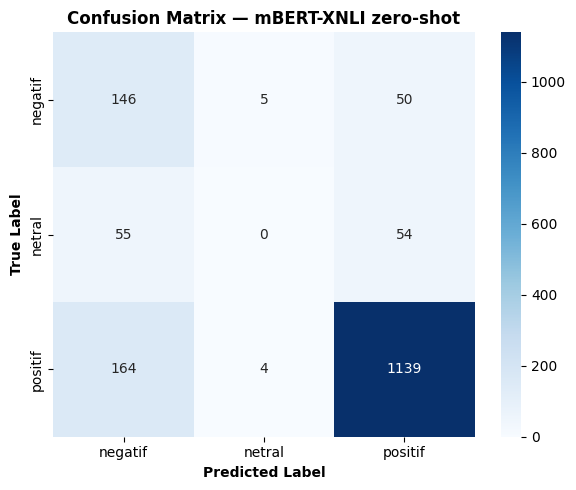

   💾 Progres disimpan (2 model selesai)


In [ ]:
# Model 2: mBERT-XNLI zero-shot
mbert_zs_result = run_zero_shot_model(
    checkpoint  = MBERT_ZERO_SHOT_CKPT,
    model_label = "mBERT-XNLI zero-shot",
    pred_col    = "mbert_xnli_zero_shot_pred",
    score_col   = "mbert_xnli_zero_shot_score",
    batch_size  = 4
)

### 6.2 — XLM-RoBERTa Zero-Shot


===== XLM-RoBERTa zero-shot =====
Checkpoint: joeddav/xlm-roberta-large-xnli
⏳ Memuat model...


config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

✅ Model dimuat dalam 0.38 menit.
⏳ Menjalankan inferensi pada 1,617 ulasan...
   Progress: 1,617/1,617
✅ Inferensi selesai dalam 2.13 menit.

📊 Hasil Evaluasi:


,Nilai
Accuracy,87.94%
Macro Precision,58.15%
Macro Recall,62.09%
Macro F1-score,58.85%
Weighted F1-score,86.12%



📊 Classification Report per Kelas:


,Kelas,Precision,Recall,F1-score,Support
0,negatif,67.95,87.56,76.52,201
1,netral,12.90,3.67,5.71,109
2,positif,93.59,95.03,94.31,1307


   💾 Confusion matrix disimpan: cm_xlm_roberta_zero_shot.png


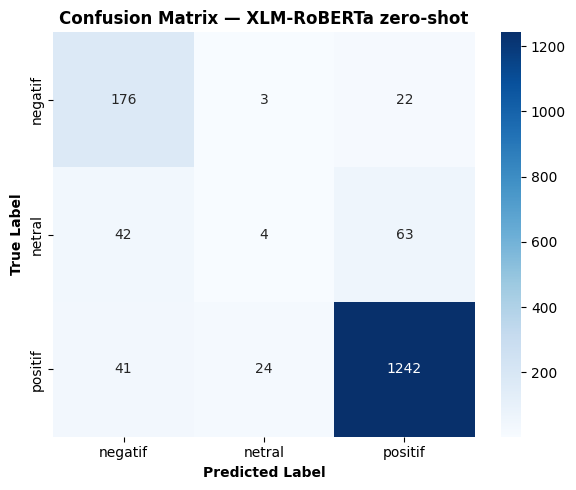

   💾 Progres disimpan (3 model selesai)


In [ ]:
# Model 3: XLM-RoBERTa zero-shot
xlmr_zs_result = run_zero_shot_model(
    checkpoint  = XLMR_ZERO_SHOT_CKPT,
    model_label = "XLM-RoBERTa zero-shot",
    pred_col    = "xlm_roberta_zero_shot_pred",
    score_col   = "xlm_roberta_zero_shot_score",
    batch_size  = 8
)

## Section 7 — Evaluasi Model 4 & 5: Fine-Tuned Classification

Pendekatan *fine-tuning* dilakukan dengan melatih ulang model *pre-trained*
menggunakan `train set` yang telah memiliki proxy label sentimen.

**Alur pelatihan:**
1. Menambahkan *classification head* berkapasitas tiga kelas di atas model dasar
2. Melatih model menggunakan `train set` selama 3 epoch
3. Mengevaluasi pada `validation set` di setiap akhir epoch
4. Memilih *checkpoint* dengan **macro F1 validasi tertinggi** secara otomatis
   (`load_best_model_at_end=True`, `metric_for_best_model='macro_f1'`)
5. Menguji model final pada `test set` yang sama dengan model lainnya

**Konfigurasi hyperparameter** ditetapkan seragam untuk kedua arsitektur
agar perbandingan bersifat *apple-to-apple*.

In [ ]:
# Tampilkan konfigurasi hyperparameter
config_df = pd.DataFrame([
    {"Parameter": "Seed",              "Nilai": SEED},
    {"Parameter": "Max length",        "Nilai": MAX_LENGTH},
    {"Parameter": "Epoch",             "Nilai": NUM_EPOCHS},
    {"Parameter": "Learning rate",     "Nilai": LEARNING_RATE},
    {"Parameter": "Train batch size",  "Nilai": TRAIN_BATCH_SIZE},
    {"Parameter": "Eval batch size",   "Nilai": EVAL_BATCH_SIZE},
    {"Parameter": "Label order",       "Nilai": ", ".join(LABEL_ORDER)},
])

print("⚙️  KONFIGURASI EKSPERIMEN FINE-TUNING")
display(config_df)

⚙️  KONFIGURASI EKSPERIMEN FINE-TUNING


,Parameter,Nilai
0,Seed,42
1,Max length,128
2,Epoch,3
3,Learning rate,0.00002
4,Train batch size,16
5,Eval batch size,32
6,Label order,"negatif, netral, positif"


In [ ]:
# Konversi label teks menjadi label numerik
train_df["label"] = train_df["proxy_sentiment"].map(label2id)
val_df["label"]   = val_df["proxy_sentiment"].map(label2id)
test_df["label"]  = test_df["proxy_sentiment"].map(label2id)

print("✅ Konversi label selesai")
print(f"   Mapping: {label2id}")
print(f"\n📊 Distribusi label pada train set:")
print(train_df["proxy_sentiment"].value_counts())

train_df[["proxy_sentiment", "label"]].head(3)

✅ Konversi label selesai
   Mapping: {'negatif': 0, 'netral': 1, 'positif': 2}

📊 Distribusi label pada train set:
proxy_sentiment
positif    6098
negatif     937
netral      508
Name: count, dtype: int64


,proxy_sentiment,label
0,positif,2
1,positif,2
2,negatif,0


In [ ]:
# Fungsi konfigurasi training dan metrik
def make_training_args(output_dir):
    """
    Membuat TrainingArguments dengan konfigurasi seragam.

    Catatan kompatibilitas:
    Nama parameter untuk strategi evaluasi berbeda antar versi transformers
    ('eval_strategy' pada versi baru, 'evaluation_strategy' pada versi lama).
    Fungsi ini mencoba keduanya secara otomatis agar tidak terjadi error.
    """
    base_kwargs = dict(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        save_strategy="epoch",
        save_total_limit=1,          # simpan 1 checkpoint terbaik → hemat disk
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        seed=SEED,
        logging_steps=50,
        report_to="none",
        fp16=torch.cuda.is_available(),   # mixed precision → training lebih cepat
    )

    # Coba nama parameter versi baru terlebih dahulu
    try:
        return TrainingArguments(eval_strategy="epoch", **base_kwargs)
    except TypeError:
        # Fallback untuk transformers versi lama
        return TrainingArguments(evaluation_strategy="epoch", **base_kwargs)


def compute_metrics(eval_pred):
    """Menghitung metrik evaluasi pada setiap akhir epoch."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    return {
        "accuracy"        : acc,
        "macro_precision" : p_macro,
        "macro_recall"    : r_macro,
        "macro_f1"        : f1_macro,
        "weighted_f1"     : f1_weighted,
    }


# Uji cepat pembuatan TrainingArguments (tanpa menjalankan training)
try:
    _test_args = make_training_args("./_test_args")
    _strategy = getattr(_test_args, "eval_strategy", None) or \
                getattr(_test_args, "evaluation_strategy", None)
    print("✅ TrainingArguments berhasil dibuat — konfigurasi kompatibel.")
    print(f"   Strategi evaluasi : {_strategy}")
    print(f"   Mixed precision   : {_test_args.fp16}")
    print(f"   Save total limit  : {_test_args.save_total_limit}")
    del _test_args
except Exception as e:
    print(f"❌ Gagal membuat TrainingArguments: {e}")
    raise

print("✅ Fungsi make_training_args() dan compute_metrics() siap digunakan.")

✅ TrainingArguments berhasil dibuat — konfigurasi kompatibel.
   Strategi evaluasi : IntervalStrategy.EPOCH
   Mixed precision   : True
   Save total limit  : 1
✅ Fungsi make_training_args() dan compute_metrics() siap digunakan.


In [ ]:
# Kelas Dataset berbasis PyTorch
# Digunakan sebagai pengganti `datasets.Dataset` dari Hugging Face.
#
# Alasan: pustaka `datasets` melakukan pemanggilan internal ke `torchvision.io`
# saat mengonversi data ke format PyTorch. Pada versi torchvision terbaru,
# pemanggilan tersebut menimbulkan ImportError meskipun penelitian ini tidak
# menggunakan data video sama sekali. Penggunaan kelas Dataset PyTorch secara
# langsung menghindari ketergantungan pada jalur kode tersebut.

class SentimentDataset(TorchDataset):
    """
    Dataset PyTorch untuk klasifikasi sentimen berbasis Transformer.

    Args:
        texts      : daftar teks ulasan
        labels     : daftar label numerik (0=negatif, 1=netral, 2=positif)
        tokenizer  : tokenizer dari model yang digunakan
        max_length : panjang maksimum token
    """

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            max_length=max_length,
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = int(self.labels[idx])
        return item


print("✅ Kelas SentimentDataset siap digunakan.")

✅ Kelas SentimentDataset siap digunakan.


In [ ]:
# Fungsi generik untuk fine-tuning dan evaluasi
def run_finetuned_model(checkpoint, model_label, pred_col, output_dir):
    """
    Melakukan fine-tuning model pre-trained, memilih checkpoint terbaik
    berdasarkan macro F1 validasi, lalu mengevaluasi pada test set.
    """
    print(f"\n===== Fine-tuning {model_label} =====")
    print(f"Checkpoint dasar: {checkpoint}")

    final_dir = output_dir + "_final"

    # Lewati pelatihan apabila model final sudah tersedia
    # Berguna ketika sesi Colab terputus dan proses perlu dilanjutkan.
    if os.path.exists(os.path.join(final_dir, "config.json")):
        print(f"ℹ️  Model final sudah tersedia di: {final_dir}")
        print(f"   Pelatihan dilewati — model dimuat langsung untuk evaluasi.")

        tokenizer = AutoTokenizer.from_pretrained(final_dir)
        model = AutoModelForSequenceClassification.from_pretrained(final_dir)
        model.to(device)
        model.eval()

        test_dataset = SentimentDataset(
            texts=test_df[TEXT_COL].astype(str).tolist(),
            labels=test_df["label"].tolist(),
            tokenizer=tokenizer,
            max_length=MAX_LENGTH,
        )

        trainer = Trainer(
            model=model,
            args=make_training_args(output_dir),
            data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
            compute_metrics=compute_metrics,
        )

        test_output = trainer.predict(test_dataset)
        pred_ids = np.argmax(test_output.predictions, axis=1)
        test_df[pred_col] = [id2label[i] for i in pred_ids]

        result, report, cm = evaluate_predictions(
            test_df["proxy_sentiment"], test_df[pred_col], model_name=model_label
        )
        results.append(result)
        reports[model_label] = report
        conf_matrices[model_label] = cm

        metrik_df = pd.DataFrame([{
            "Accuracy"          : f"{result['accuracy']*100:.2f}%",
            "Macro Precision"   : f"{result['macro_precision']*100:.2f}%",
            "Macro Recall"      : f"{result['macro_recall']*100:.2f}%",
            "Macro F1-score"    : f"{result['macro_f1']*100:.2f}%",
            "Weighted F1-score" : f"{result['weighted_f1']*100:.2f}%",
        }])
        print("\n📊 Hasil Evaluasi pada Test Set:")
        display(metrik_df.T.rename(columns={0: "Nilai"}))
        print("\n📊 Classification Report per Kelas:")
        display(format_report(report))

        safe_name = model_label.lower().replace(" ", "_").replace("-", "_")
        show_confusion_matrix(cm, f"Confusion Matrix — {model_label}",
                              save_as=f"cm_{safe_name}.png")

        simpan_progres()
        del model, trainer, tokenizer, test_dataset
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return result, {}

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    # Siapkan dataset menggunakan kelas SentimentDataset (berbasis PyTorch)
    print("⏳ Tokenisasi dataset...")
    train_dataset = SentimentDataset(
        texts=train_df[TEXT_COL].astype(str).tolist(),
        labels=train_df["label"].tolist(),
        tokenizer=tokenizer,
        max_length=MAX_LENGTH,
    )
    val_dataset = SentimentDataset(
        texts=val_df[TEXT_COL].astype(str).tolist(),
        labels=val_df["label"].tolist(),
        tokenizer=tokenizer,
        max_length=MAX_LENGTH,
    )
    test_dataset = SentimentDataset(
        texts=test_df[TEXT_COL].astype(str).tolist(),
        labels=test_df["label"].tolist(),
        tokenizer=tokenizer,
        max_length=MAX_LENGTH,
    )
    print(f"   Train : {len(train_dataset):,} sampel")
    print(f"   Val   : {len(val_dataset):,} sampel")
    print(f"   Test  : {len(test_dataset):,} sampel")

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Muat model dengan classification head 3 kelas
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=3, id2label=id2label, label2id=label2id
    )
    model.to(device)

    trainer = Trainer(
        model=model,
        args=make_training_args(output_dir),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Pelatihan
    print("⏳ Memulai pelatihan...")
    start_time = time.time()
    trainer.train()
    elapsed = time.time() - start_time
    print(f"✅ Pelatihan selesai dalam {elapsed/60:.2f} menit.")

    # Metrik pada validation set (checkpoint terbaik)
    val_metrics = trainer.evaluate(eval_dataset=val_dataset)
    print(f"\n📊 Metrik pada validation set (checkpoint terbaik):")
    val_display = pd.DataFrame([{
        k.replace("eval_", ""): (f"{v*100:.2f}%" if isinstance(v, float) and 0 <= v <= 1 else v)
        for k, v in val_metrics.items()
        if k.startswith("eval_") and k != "eval_runtime"
    }])
    display(val_display.T.rename(columns={0: "Nilai"}))

    # Prediksi pada test set
    print("\n⏳ Melakukan prediksi pada test set...")
    test_output = trainer.predict(test_dataset)
    pred_ids = np.argmax(test_output.predictions, axis=1)
    test_df[pred_col] = [id2label[i] for i in pred_ids]

    # Evaluasi akhir
    result, report, cm = evaluate_predictions(
        test_df["proxy_sentiment"], test_df[pred_col], model_name=model_label
    )

    results.append(result)
    reports[model_label] = report
    conf_matrices[model_label] = cm

    metrik_df = pd.DataFrame([{
        "Accuracy"          : f"{result['accuracy']*100:.2f}%",
        "Macro Precision"   : f"{result['macro_precision']*100:.2f}%",
        "Macro Recall"      : f"{result['macro_recall']*100:.2f}%",
        "Macro F1-score"    : f"{result['macro_f1']*100:.2f}%",
        "Weighted F1-score" : f"{result['weighted_f1']*100:.2f}%",
    }])
    print("\n📊 Hasil Evaluasi pada Test Set:")
    display(metrik_df.T.rename(columns={0: "Nilai"}))

    print("\n📊 Classification Report per Kelas:")
    display(format_report(report))

    safe_name = model_label.lower().replace(" ", "_").replace("-", "_")
    show_confusion_matrix(cm, f"Confusion Matrix — {model_label}",
                          save_as=f"cm_{safe_name}.png")

    # Simpan model final
    trainer.save_model(final_dir)
    tokenizer.save_pretrained(final_dir)
    print(f"   💾 Model final disimpan: {final_dir}")

    # Simpan progres agar aman dari pemutusan sesi
    simpan_progres()

    # Bersihkan memori
    del model, trainer, tokenizer
    del train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, val_metrics


print("✅ Fungsi run_finetuned_model() siap digunakan.")

✅ Fungsi run_finetuned_model() siap digunakan.


### 7.1 — mBERT Fine-Tuned


===== Fine-tuning mBERT fine-tuned =====
Checkpoint dasar: bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...


📊 Hasil Evaluasi pada Test Set:


,Nilai
Accuracy,88.13%
Macro Precision,65.72%
Macro Recall,63.00%
Macro F1-score,63.82%
Weighted F1-score,87.14%



📊 Classification Report per Kelas:


,Kelas,Precision,Recall,F1-score,Support
0,negatif,74.51,75.62,75.06,201
1,netral,29.69,17.43,21.97,109
2,positif,92.96,95.94,94.43,1307


   💾 Confusion matrix disimpan: cm_mbert_fine_tuned.png


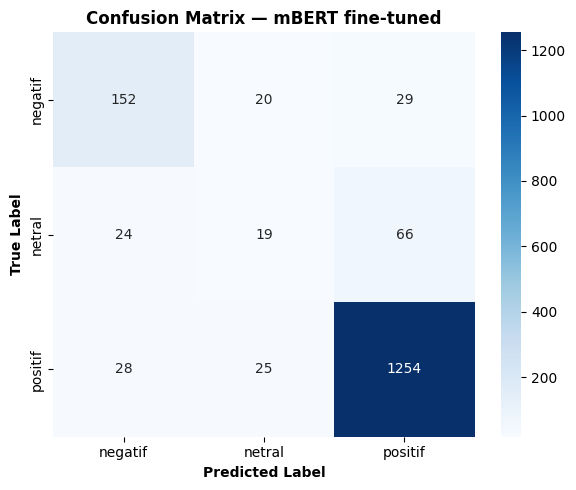

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Model final disimpan: /content/drive/MyDrive/Skripsi_NLP_Attraction/model/mbert_finetuned_final
   💾 Progres disimpan (4 model selesai)


In [ ]:
# Model 4: mBERT fine-tuned
mbert_ft_result, mbert_ft_val_metrics = run_finetuned_model(
    checkpoint  = MBERT_FINETUNE_CKPT,
    model_label = "mBERT fine-tuned",
    pred_col    = "mbert_finetuned_pred",
    output_dir  = os.path.join(MODEL_BASE, "mbert_finetuned")
)

### 7.2 — XLM-RoBERTa Fine-Tuned


===== Fine-tuning XLM-RoBERTa fine-tuned =====
Checkpoint dasar: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...


📊 Hasil Evaluasi pada Test Set:


,Nilai
Accuracy,89.98%
Macro Precision,72.29%
Macro Recall,69.37%
Macro F1-score,70.74%
Weighted F1-score,89.68%



📊 Classification Report per Kelas:


,Kelas,Precision,Recall,F1-score,Support
0,negatif,86.02,79.60,82.69,201
1,netral,36.46,32.11,34.15,109
2,positif,94.38,96.40,95.38,1307


   💾 Confusion matrix disimpan: cm_xlm_roberta_fine_tuned.png


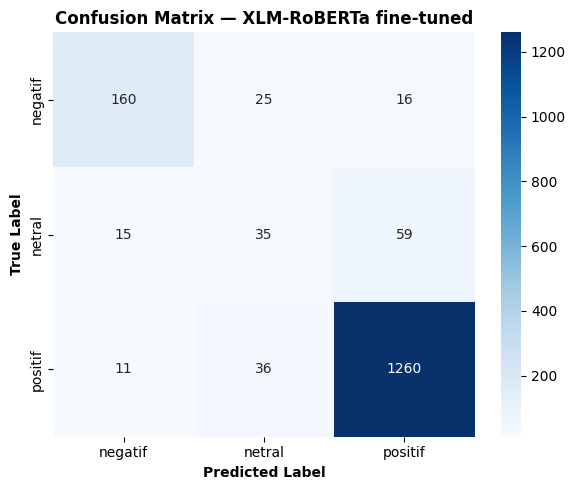

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   💾 Model final disimpan: /content/drive/MyDrive/Skripsi_NLP_Attraction/model/xlm_roberta_finetuned_final
   💾 Progres disimpan (5 model selesai)


In [ ]:
# Model 5: XLM-RoBERTa fine-tuned
xlmr_ft_result, xlmr_ft_val_metrics = run_finetuned_model(
    checkpoint  = XLMR_FINETUNE_CKPT,
    model_label = "XLM-RoBERTa fine-tuned",
    pred_col    = "xlm_roberta_finetuned_pred",
    output_dir  = os.path.join(MODEL_BASE, "xlm_roberta_finetuned")
)

## Section 8 — Perbandingan Hasil Evaluasi Utama

Rekapitulasi hasil evaluasi seluruh model pada **test set yang sama**,
diurutkan berdasarkan **macro F1-score** dari yang tertinggi.

*Macro F1-score* dipilih sebagai metrik utama karena memberikan bobot setara
terhadap setiap kelas sentimen, sehingga lebih representatif pada kondisi
distribusi kelas yang tidak seimbang.

In [ ]:
# Susun tabel perbandingan utama
main_results = pd.DataFrame(results)

main_results = main_results[[
    "model", "n_data", "accuracy",
    "macro_precision", "macro_recall", "macro_f1",
    "weighted_precision", "weighted_recall", "weighted_f1",
]]

# Konversi ke persen
METRIC_COLS = [
    "accuracy", "macro_precision", "macro_recall", "macro_f1",
    "weighted_precision", "weighted_recall", "weighted_f1",
]

main_results_percent = main_results.copy()
for col in METRIC_COLS:
    main_results_percent[col] = (main_results_percent[col] * 100).round(2)

# Urutkan berdasarkan macro F1
main_results_percent_sorted = main_results_percent.sort_values(
    by="macro_f1", ascending=False
).reset_index(drop=True)

# Tambahkan kolom peringkat
main_results_percent_sorted.insert(0, "Peringkat", range(1, len(main_results_percent_sorted) + 1))

print("=" * 70)
print("📊 PERBANDINGAN HASIL EVALUASI UTAMA SEMUA MODEL")
print("   (diurutkan berdasarkan Macro F1-score)")
print("=" * 70)
display(main_results_percent_sorted)

# Identifikasi model terbaik
best_model = main_results_percent_sorted.iloc[0]
print(f"\n🏆 MODEL TERBAIK: {best_model['model']}")
print(f"   Accuracy          : {best_model['accuracy']:.2f}%")
print(f"   Macro F1-score    : {best_model['macro_f1']:.2f}%")
print(f"   Weighted F1-score : {best_model['weighted_f1']:.2f}%")

📊 PERBANDINGAN HASIL EVALUASI UTAMA SEMUA MODEL
   (diurutkan berdasarkan Macro F1-score)


,Peringkat,model,n_data,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,1,GPT prompt-based zero-shot,1617,83.67,68.36,79.39,70.88,91.50,83.67,86.55
1,2,XLM-RoBERTa fine-tuned,1617,89.98,72.29,69.37,70.74,89.44,89.98,89.68
2,3,mBERT fine-tuned,1617,88.13,65.72,63.00,63.82,86.40,88.13,87.14
3,4,XLM-RoBERTa zero-shot,1617,87.94,58.15,62.09,58.85,84.97,87.94,86.12
4,5,mBERT-XNLI zero-shot,1617,79.47,43.88,53.26,46.97,79.04,79.47,78.62



🏆 MODEL TERBAIK: GPT prompt-based zero-shot
   Accuracy          : 83.67%
   Macro F1-score    : 70.88%
   Weighted F1-score : 86.55%


## Section 9 — Visualisasi Perbandingan Model

Visualisasi perbandingan performa antar model untuk memperjelas
perbedaan capaian masing-masing pendekatan.

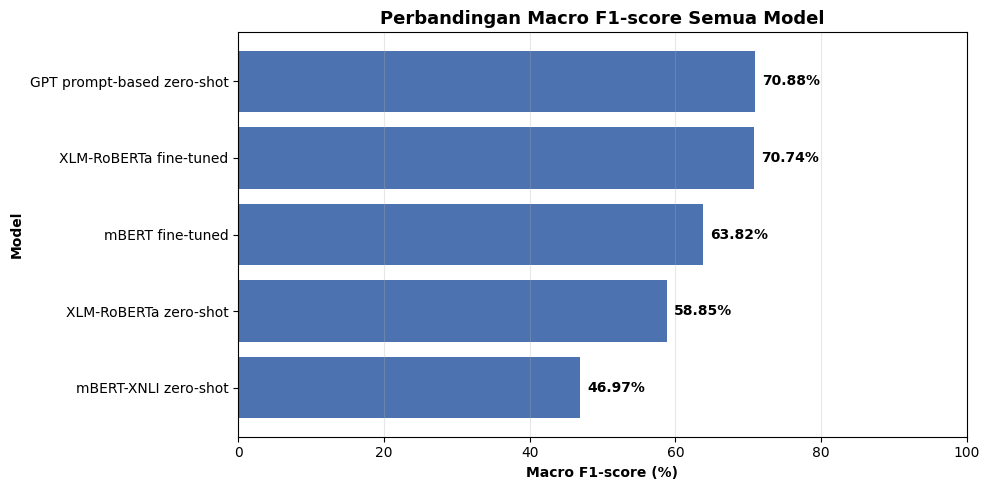

💾 Disimpan: perbandingan_macro_f1_semua_model.png


In [ ]:
# Visualisasi perbandingan Macro F1-score
plot_df = main_results_percent_sorted.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(plot_df["model"], plot_df["macro_f1"], color="#4C72B0")
plt.xlabel("Macro F1-score (%)", fontweight="bold")
plt.ylabel("Model", fontweight="bold")
plt.title("Perbandingan Macro F1-score Semua Model", fontweight="bold", fontsize=13)
plt.xlim(0, 100)

for bar, val in zip(bars, plot_df["macro_f1"]):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}%", va="center", fontweight="bold", fontsize=10)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("perbandingan_macro_f1_semua_model.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Disimpan: perbandingan_macro_f1_semua_model.png")

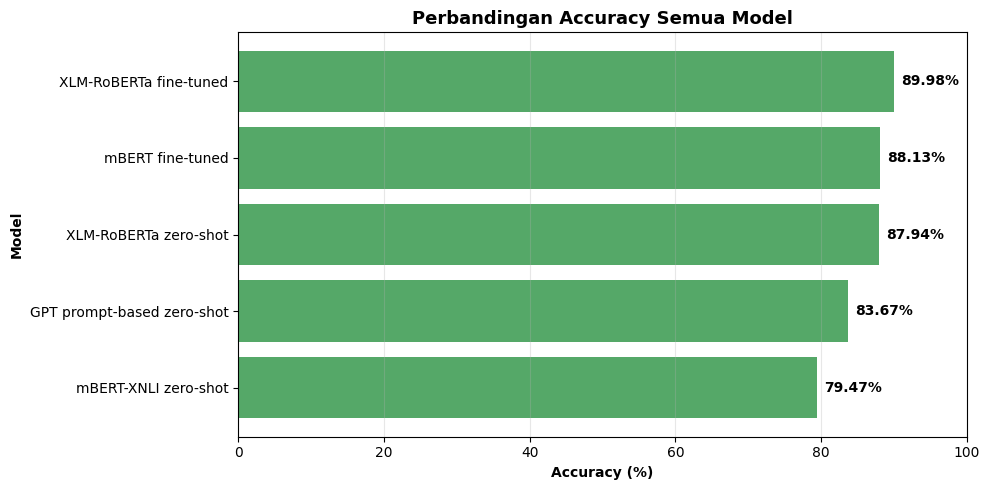

💾 Disimpan: perbandingan_accuracy_semua_model.png


In [ ]:
# Visualisasi perbandingan Accuracy
plot_df = main_results_percent_sorted.sort_values("accuracy", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(plot_df["model"], plot_df["accuracy"], color="#55A868")
plt.xlabel("Accuracy (%)", fontweight="bold")
plt.ylabel("Model", fontweight="bold")
plt.title("Perbandingan Accuracy Semua Model", fontweight="bold", fontsize=13)
plt.xlim(0, 100)

for bar, val in zip(bars, plot_df["accuracy"]):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}%", va="center", fontweight="bold", fontsize=10)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("perbandingan_accuracy_semua_model.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Disimpan: perbandingan_accuracy_semua_model.png")

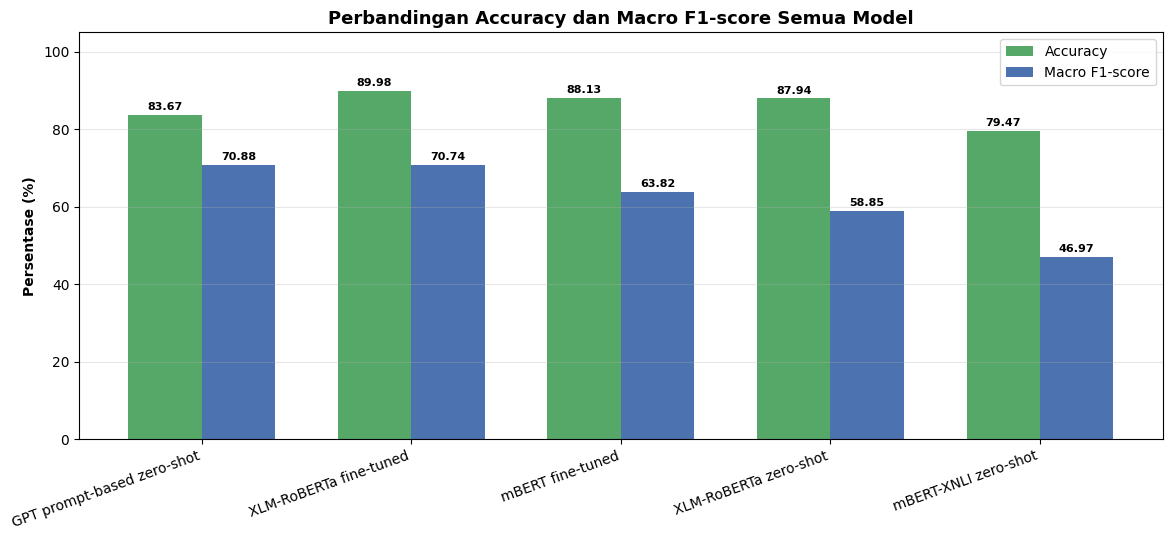

💾 Disimpan: perbandingan_accuracy_vs_macrof1.png


In [ ]:
# Visualisasi gabungan: Accuracy vs Macro F1
plot_df = main_results_percent_sorted.copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5.5))
b1 = ax.bar(x - width/2, plot_df["accuracy"], width, label="Accuracy", color="#55A868")
b2 = ax.bar(x + width/2, plot_df["macro_f1"], width, label="Macro F1-score", color="#4C72B0")

ax.set_ylabel("Persentase (%)", fontweight="bold")
ax.set_title("Perbandingan Accuracy dan Macro F1-score Semua Model",
             fontweight="bold", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [b1, b2]:
    ax.bar_label(bars, fmt="%.2f", fontsize=8, fontweight="bold", padding=2)

plt.tight_layout()
plt.savefig("perbandingan_accuracy_vs_macrof1.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Disimpan: perbandingan_accuracy_vs_macrof1.png")

## Section 10 — Analisis Performa per Kelas Sentimen

Perbandingan F1-score setiap model pada masing-masing kelas sentimen.
Analisis ini penting untuk mengidentifikasi kelas yang paling sulit dikenali
oleh model, khususnya **kelas netral** yang merupakan kelas minoritas.

In [ ]:
# Susun tabel perbandingan F1-score per kelas
per_class_rows = []

for model_label, report in reports.items():
    row = {"Model": model_label}
    for kelas in LABEL_ORDER:
        row[f"F1 {kelas}"] = round(report[kelas]["f1-score"] * 100, 2)
    per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)

# Urutkan sesuai urutan peringkat pada tabel utama
urutan_model = main_results_percent_sorted["model"].tolist()
per_class_df["_urut"] = per_class_df["Model"].apply(lambda m: urutan_model.index(m))
per_class_df = per_class_df.sort_values("_urut").drop(columns=["_urut"]).reset_index(drop=True)

print("=" * 70)
print("📊 PERBANDINGAN F1-SCORE PER KELAS SENTIMEN")
print("=" * 70)
display(per_class_df)

print(f"\n💡 Catatan:")
print(f"   Kelas 'netral' konsisten memperoleh F1-score terendah pada")
print(f"   seluruh model. Hal ini disebabkan jumlah data netral yang paling")
print(f"   sedikit serta karakteristik sentimen netral yang ambigu.")

📊 PERBANDINGAN F1-SCORE PER KELAS SENTIMEN


,Model,F1 negatif,F1 netral,F1 positif
0,GPT prompt-based zero-shot,86.38,35.42,90.84
1,XLM-RoBERTa fine-tuned,82.69,34.15,95.38
2,mBERT fine-tuned,75.06,21.97,94.43
3,XLM-RoBERTa zero-shot,76.52,5.71,94.31
4,mBERT-XNLI zero-shot,51.59,0.00,89.33



💡 Catatan:
   Kelas 'netral' konsisten memperoleh F1-score terendah pada
   seluruh model. Hal ini disebabkan jumlah data netral yang paling
   sedikit serta karakteristik sentimen netral yang ambigu.


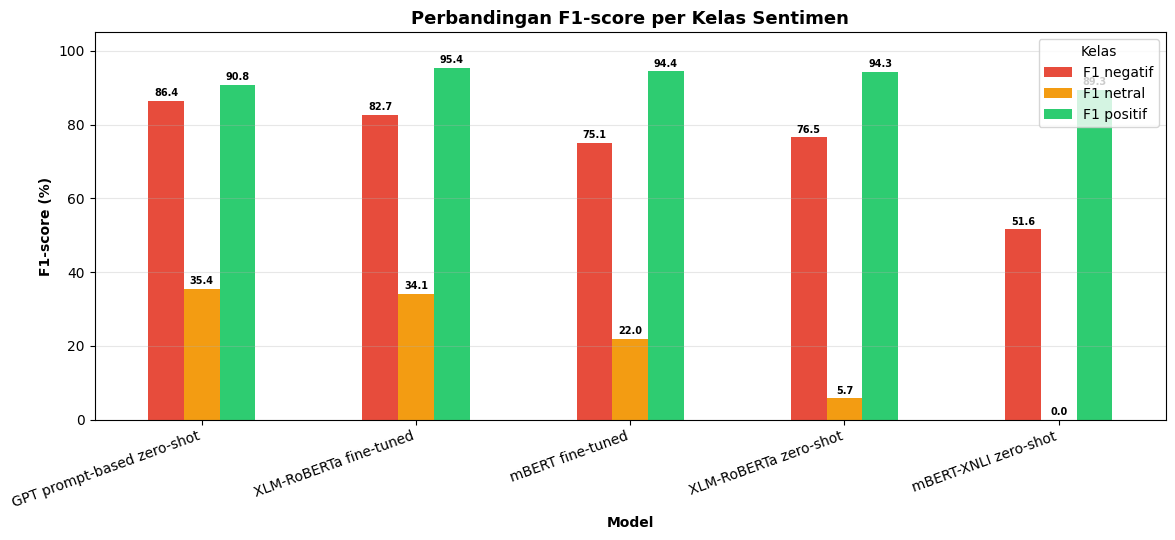

💾 Disimpan: perbandingan_f1_per_kelas.png


In [ ]:
# Visualisasi F1-score per kelas
plot_data = per_class_df.set_index("Model")

fig, ax = plt.subplots(figsize=(12, 5.5))
plot_data.plot(kind="bar", ax=ax,
               color=["#e74c3c", "#f39c12", "#2ecc71"])

ax.set_ylabel("F1-score (%)", fontweight="bold")
ax.set_xlabel("Model", fontweight="bold")
ax.set_title("Perbandingan F1-score per Kelas Sentimen",
             fontweight="bold", fontsize=13)
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Kelas", loc="upper right")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=7, fontweight="bold", padding=2)

plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout()
plt.savefig("perbandingan_f1_per_kelas.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Disimpan: perbandingan_f1_per_kelas.png")

## Section 11 — Perbandingan Pendekatan Zero-Shot vs Fine-Tuning

Analisis peningkatan performa yang diperoleh melalui proses *fine-tuning*
dibandingkan pendekatan *zero-shot* pada arsitektur yang sama.

In [ ]:
# Bandingkan zero-shot vs fine-tuned per arsitektur
def get_macro_f1(model_label):
    """Mengambil nilai macro F1 (persen) untuk satu model."""
    row = main_results_percent[main_results_percent["model"] == model_label]
    return float(row["macro_f1"].iloc[0]) if len(row) > 0 else None


perbandingan_pendekatan = []

pasangan = [
    ("mBERT",       "mBERT-XNLI zero-shot",  "mBERT fine-tuned"),
    ("XLM-RoBERTa", "XLM-RoBERTa zero-shot", "XLM-RoBERTa fine-tuned"),
]

for arsitektur, zs_label, ft_label in pasangan:
    zs_f1 = get_macro_f1(zs_label)
    ft_f1 = get_macro_f1(ft_label)

    if zs_f1 is not None and ft_f1 is not None:
        perbandingan_pendekatan.append({
            "Arsitektur"      : arsitektur,
            "Zero-shot (%)"   : zs_f1,
            "Fine-tuned (%)"  : ft_f1,
            "Peningkatan (pp)": round(ft_f1 - zs_f1, 2),
        })

perbandingan_df = pd.DataFrame(perbandingan_pendekatan)

print("=" * 70)
print("📊 PERBANDINGAN ZERO-SHOT vs FINE-TUNING (Macro F1-score)")
print("=" * 70)
display(perbandingan_df)

print(f"\n💡 Catatan: 'pp' = percentage point (selisih poin persentase)")

📊 PERBANDINGAN ZERO-SHOT vs FINE-TUNING (Macro F1-score)


,Arsitektur,Zero-shot (%),Fine-tuned (%),Peningkatan (pp)
0,mBERT,46.97,63.82,16.85
1,XLM-RoBERTa,58.85,70.74,11.89



💡 Catatan: 'pp' = percentage point (selisih poin persentase)


## Section 12 — Evaluasi Per Bahasa

Evaluasi dilakukan secara terpisah pada setiap bahasa dalam dataset
(Bahasa Inggris, Bahasa Indonesia, dan Bahasa Spanyol) untuk menganalisis
konsistensi performa model pada karakteristik bahasa yang berbeda.

Evaluasi ini penting karena dataset penelitian bersifat multibahasa dan
seluruh model yang digunakan merupakan model multilingual.

> **Catatan:** Evaluasi per bahasa dijalankan untuk **seluruh lima model**
> menggunakan `MODEL_REGISTRY` sebagai acuan, sehingga tidak ada model
> yang terlewat.

In [ ]:
# Fungsi evaluasi per bahasa
def evaluate_by_language(df, pred_col, model_name):
    """
    Mengevaluasi performa satu model secara terpisah pada setiap bahasa.
    """
    rows = []

    for lang in sorted(df["language"].dropna().unique()):
        subset = df[df["language"] == lang].copy()

        if len(subset) == 0:
            continue

        result, _, _ = evaluate_predictions(
            subset["proxy_sentiment"],
            subset[pred_col],
            model_name=model_name
        )

        result["language"] = lang
        result["n_data"]   = len(subset)
        rows.append(result)

    return pd.DataFrame(rows)


print("✅ Fungsi evaluate_by_language() siap digunakan.")

✅ Fungsi evaluate_by_language() siap digunakan.


In [ ]:
# Jalankan evaluasi per bahasa untuk SELURUH model di registry
eval_lang_dfs = []
model_terlewat = []

print("⏳ Menjalankan evaluasi per bahasa untuk seluruh model...\n")

for m in MODEL_REGISTRY:
    pred_col    = m["pred_col"]
    model_label = m["label"]

    if pred_col in test_df.columns:
        eval_lang_dfs.append(
            evaluate_by_language(test_df, pred_col, model_label)
        )
        print(f"   ✅ {model_label}")
    else:
        model_terlewat.append(model_label)
        print(f"   ⚠️  {model_label} — kolom '{pred_col}' tidak ditemukan, DILEWATI")

# Peringatan jika ada model yang terlewat
if model_terlewat:
    print(f"\n⚠️  PERINGATAN: {len(model_terlewat)} model tidak dievaluasi per bahasa:")
    for m in model_terlewat:
        print(f"      - {m}")
    print(f"   Pastikan seluruh model telah dijalankan sebelum tahap ini.")
else:
    print(f"\n✅ Seluruh {len(MODEL_REGISTRY)} model berhasil dievaluasi per bahasa.")

eval_by_language = pd.concat(eval_lang_dfs, ignore_index=True)

⏳ Menjalankan evaluasi per bahasa untuk seluruh model...

   ✅ GPT prompt-based zero-shot
   ✅ mBERT-XNLI zero-shot
   ✅ XLM-RoBERTa zero-shot
   ✅ mBERT fine-tuned
   ✅ XLM-RoBERTa fine-tuned

✅ Seluruh 5 model berhasil dievaluasi per bahasa.


In [ ]:
# Susun tabel evaluasi per bahasa dalam persen
eval_by_language_percent = eval_by_language.copy()

for col in METRIC_COLS:
    eval_by_language_percent[col] = (eval_by_language_percent[col] * 100).round(2)

# Susun ulang kolom agar lebih mudah dibaca
eval_by_language_percent = eval_by_language_percent[[
    "model", "language", "n_data", "accuracy",
    "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
]]

eval_by_language_percent = eval_by_language_percent.rename(columns={
    "model"           : "Model",
    "language"        : "Bahasa",
    "n_data"          : "n",
    "accuracy"        : "Accuracy",
    "macro_precision" : "Macro Precision",
    "macro_recall"    : "Macro Recall",
    "macro_f1"        : "Macro F1-score",
    "weighted_f1"     : "Weighted F1-score",
})

print("=" * 70)
print("📊 HASIL EVALUASI PER BAHASA — SELURUH MODEL")
print("=" * 70)
display(eval_by_language_percent)

📊 HASIL EVALUASI PER BAHASA — SELURUH MODEL


,Model,Bahasa,n,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score
0,GPT prompt-based zero-shot,en,1047,86.25,71.64,80.22,74.27,88.03
1,GPT prompt-based zero-shot,es,37,89.19,78.33,84.34,80.89,89.80
2,GPT prompt-based zero-shot,id,533,78.24,62.73,78.04,64.22,84.01
3,mBERT-XNLI zero-shot,en,1047,78.99,45.29,55.48,48.69,77.48
4,mBERT-XNLI zero-shot,es,37,70.27,41.01,47.25,43.83,66.72
5,mBERT-XNLI zero-shot,id,533,81.05,39.48,46.26,41.46,81.81
6,XLM-RoBERTa zero-shot,en,1047,86.82,59.67,62.08,58.97,84.37
7,XLM-RoBERTa zero-shot,es,37,86.49,53.17,61.90,57.10,81.86
8,XLM-RoBERTa zero-shot,id,533,90.24,55.88,62.45,58.44,89.88
9,mBERT fine-tuned,en,1047,87.11,66.59,64.37,64.94,86.05


In [ ]:
# Tabel pivot: Macro F1 per model × bahasa
pivot_f1 = eval_by_language_percent.pivot(
    index="Model", columns="Bahasa", values="Macro F1-score"
)

# Urutkan sesuai peringkat model pada evaluasi utama
urutan_model = main_results_percent_sorted["model"].tolist()
pivot_f1 = pivot_f1.reindex([m for m in urutan_model if m in pivot_f1.index])

print("=" * 70)
print("📊 RINGKASAN MACRO F1-SCORE PER BAHASA (%)")
print("=" * 70)
display(pivot_f1)

# Tampilkan jumlah data per bahasa pada test set
print(f"\n📊 Jumlah data test set per bahasa:")
lang_counts = test_df["language"].value_counts().sort_index()
for lang, count in lang_counts.items():
    print(f"   {lang:<5}: {count:>5,} ulasan ({count/len(test_df)*100:>5.2f}%)")

print(f"\n⚠️  Catatan interpretasi:")
print(f"   Hasil evaluasi pada bahasa dengan jumlah data kecil perlu")
print(f"   ditafsirkan secara hati-hati karena lebih sensitif terhadap")
print(f"   perubahan sejumlah kecil prediksi benar atau salah.")

📊 RINGKASAN MACRO F1-SCORE PER BAHASA (%)


Bahasa,en,es,id
Model,,,
GPT prompt-based zero-shot,74.27,80.89,64.22
XLM-RoBERTa fine-tuned,72.13,77.13,63.84
mBERT fine-tuned,64.94,55.22,60.08
XLM-RoBERTa zero-shot,58.97,57.10,58.44
mBERT-XNLI zero-shot,48.69,43.83,41.46



📊 Jumlah data test set per bahasa:
   en   : 1,047 ulasan (64.75%)
   es   :    37 ulasan ( 2.29%)
   id   :   533 ulasan (32.96%)

⚠️  Catatan interpretasi:
   Hasil evaluasi pada bahasa dengan jumlah data kecil perlu
   ditafsirkan secara hati-hati karena lebih sensitif terhadap
   perubahan sejumlah kecil prediksi benar atau salah.


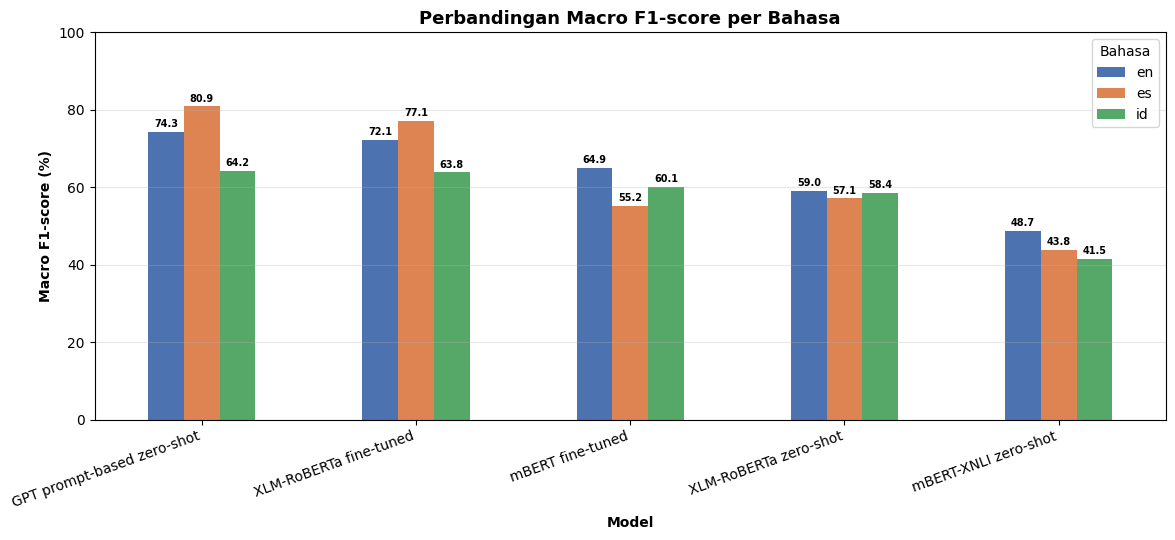

💾 Disimpan: perbandingan_macro_f1_per_bahasa.png


In [ ]:
# Visualisasi Macro F1 per bahasa
fig, ax = plt.subplots(figsize=(12, 5.5))

pivot_f1.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])

ax.set_ylabel("Macro F1-score (%)", fontweight="bold")
ax.set_xlabel("Model", fontweight="bold")
ax.set_title("Perbandingan Macro F1-score per Bahasa", fontweight="bold", fontsize=13)
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Bahasa")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=7, fontweight="bold", padding=2)

plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout()
plt.savefig("perbandingan_macro_f1_per_bahasa.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Disimpan: perbandingan_macro_f1_per_bahasa.png")

## Section 13 — Ekspor Hasil Evaluasi

Seluruh hasil evaluasi diekspor ke dalam satu berkas Excel dengan
*sheet* terpisah untuk memudahkan penyusunan laporan:

- **Skenario_Evaluasi** — daftar model dan konfigurasinya
- **Konfigurasi_Eksperimen** — hyperparameter fine-tuning
- **Evaluasi_Utama** — perbandingan metrik seluruh model
- **Evaluasi_Per_Bahasa** — hasil evaluasi terpisah per bahasa
- **F1_Per_Kelas** — perbandingan F1-score per kelas sentimen
- **ZeroShot_vs_FineTuned** — analisis peningkatan fine-tuning
- **Report_[nama model]** — classification report tiap model

In [ ]:
# Ekspor seluruh hasil evaluasi ke satu berkas Excel
OUTPUT_EXCEL = "Hasil_Evaluasi_Model.xlsx"

with pd.ExcelWriter(OUTPUT_EXCEL) as writer:
    # Sheet 1: Skenario evaluasi
    skenario_df.to_excel(writer, sheet_name="Skenario_Evaluasi", index=False)

    # Sheet 2: Konfigurasi eksperimen
    config_df.to_excel(writer, sheet_name="Konfigurasi_Eksperimen", index=False)

    # Sheet 3: Evaluasi utama
    main_results_percent_sorted.to_excel(writer, sheet_name="Evaluasi_Utama", index=False)

    # Sheet 4: Evaluasi per bahasa
    eval_by_language_percent.to_excel(writer, sheet_name="Evaluasi_Per_Bahasa", index=False)

    # Sheet 5: Pivot macro F1 per bahasa
    pivot_f1.to_excel(writer, sheet_name="Pivot_F1_Per_Bahasa")

    # Sheet 6: F1 per kelas
    per_class_df.to_excel(writer, sheet_name="F1_Per_Kelas", index=False)

    # Sheet 7: Zero-shot vs fine-tuned
    perbandingan_df.to_excel(writer, sheet_name="ZeroShot_vs_FineTuned", index=False)

    # Sheet 8+: Classification report tiap model
    for model_label, report in reports.items():
        sheet_name = f"Report_{model_label}"[:31]
        sheet_name = sheet_name.replace("/", "_").replace(":", "_").replace("\\", "_")
        format_report(report).to_excel(writer, sheet_name=sheet_name, index=False)

print(f"✅ Berkas '{OUTPUT_EXCEL}' berhasil dibuat.")
print(f"\n📋 Sheet yang tersedia:")
print(f"   1. Skenario_Evaluasi")
print(f"   2. Konfigurasi_Eksperimen")
print(f"   3. Evaluasi_Utama")
print(f"   4. Evaluasi_Per_Bahasa")
print(f"   5. Pivot_F1_Per_Bahasa")
print(f"   6. F1_Per_Kelas")
print(f"   7. ZeroShot_vs_FineTuned")
for i, model_label in enumerate(reports.keys(), start=8):
    print(f"   {i}. Report_{model_label}")

✅ Berkas 'Hasil_Evaluasi_Model.xlsx' berhasil dibuat.

📋 Sheet yang tersedia:
   1. Skenario_Evaluasi
   2. Konfigurasi_Eksperimen
   3. Evaluasi_Utama
   4. Evaluasi_Per_Bahasa
   5. Pivot_F1_Per_Bahasa
   6. F1_Per_Kelas
   7. ZeroShot_vs_FineTuned
   8. Report_GPT prompt-based zero-shot
   9. Report_mBERT-XNLI zero-shot
   10. Report_XLM-RoBERTa zero-shot
   11. Report_mBERT fine-tuned
   12. Report_XLM-RoBERTa fine-tuned


In [ ]:
# Simpan test set lengkap beserta prediksi seluruh model
# Susun kolom agar rapi: metadata → label acuan → prediksi tiap model
kolom_meta = [c for c in [
    "review_id", "user_id", "nama_tempat", "id_tempat", "rating",
    "kabupaten", "provinsi", "review", "review_clean",
    "language", "language_original", "sumber", "proxy_sentiment",
] if c in test_df.columns]

kolom_prediksi = []
for m in MODEL_REGISTRY:
    if m["pred_col"] in test_df.columns:
        kolom_prediksi.append(m["pred_col"])
    if m["score_col"] and m["score_col"] in test_df.columns:
        kolom_prediksi.append(m["score_col"])

kolom_output = kolom_meta + kolom_prediksi
test_output = test_df[kolom_output].copy()

test_output.to_excel("Test_Set_Dengan_Prediksi_Semua_Model.xlsx", index=False)
test_output.to_csv("Test_Set_Dengan_Prediksi_Semua_Model.csv",
                   index=False, encoding="utf-8-sig")

print(f"✅ Test set lengkap berhasil disimpan.")
print(f"   Jumlah baris : {len(test_output):,}")
print(f"   Jumlah kolom : {len(test_output.columns)}")
print(f"\n📋 Kolom prediksi yang tersimpan:")
for col in kolom_prediksi:
    print(f"   - {col}")

✅ Test set lengkap berhasil disimpan.
   Jumlah baris : 1,617
   Jumlah kolom : 20

📋 Kolom prediksi yang tersimpan:
   - gpt_pred
   - mbert_xnli_zero_shot_pred
   - mbert_xnli_zero_shot_score
   - xlm_roberta_zero_shot_pred
   - xlm_roberta_zero_shot_score
   - mbert_finetuned_pred
   - xlm_roberta_finetuned_pred


## Section 14 — Ringkasan Akhir dan Penentuan Model Terbaik

Rekapitulasi keseluruhan hasil eksperimen dan penentuan model yang
akan digunakan untuk proses pelabelan dataset akhir.

In [ ]:
# Ringkasan akhir
best = main_results_percent_sorted.iloc[0]
second = main_results_percent_sorted.iloc[1]

print("=" * 70)
print("🎉 NOTEBOOK 03 SELESAI!")
print("=" * 70)

print(f"\n📊 RINGKASAN HASIL EKSPERIMEN")
print(f"┌────────────────────────────────────────────────────────────────┐")
print(f"│  Jumlah model dievaluasi : {len(main_results_percent_sorted):>2}                                  │")
print(f"│  Jumlah data test set    : {int(best['n_data']):>5,}                               │")
print(f"│  Metrik utama            : Macro F1-score                      │")
print(f"└────────────────────────────────────────────────────────────────┘")

print(f"\n🏆 MODEL TERBAIK: {best['model']}")
print(f"   ├─ Accuracy          : {best['accuracy']:.2f}%")
print(f"   ├─ Macro Precision   : {best['macro_precision']:.2f}%")
print(f"   ├─ Macro Recall      : {best['macro_recall']:.2f}%")
print(f"   ├─ Macro F1-score    : {best['macro_f1']:.2f}%")
print(f"   └─ Weighted F1-score : {best['weighted_f1']:.2f}%")

print(f"\n🥈 PERINGKAT KEDUA: {second['model']}")
print(f"   ├─ Macro F1-score    : {second['macro_f1']:.2f}%")
print(f"   └─ Selisih dari #1   : {best['macro_f1'] - second['macro_f1']:.2f} pp")

print(f"\n📁 BERKAS YANG DIHASILKAN:")
print(f"   1. {OUTPUT_EXCEL}")
print(f"   2. Test_Set_Dengan_Prediksi_Semua_Model.xlsx / .csv")
print(f"   3. Visualisasi (.png):")
print(f"      - perbandingan_macro_f1_semua_model.png")
print(f"      - perbandingan_accuracy_semua_model.png")
print(f"      - perbandingan_accuracy_vs_macrof1.png")
print(f"      - perbandingan_f1_per_kelas.png")
print(f"      - perbandingan_macro_f1_per_bahasa.png")
print(f"      - cm_[nama model].png  (confusion matrix tiap model)")

print(f"\n➡️  Model '{best['model']}' ditetapkan sebagai model terpilih")
print(f"   untuk proses pelabelan sentimen pada dataset akhir.")

🎉 NOTEBOOK 03 SELESAI!

📊 RINGKASAN HASIL EKSPERIMEN
┌────────────────────────────────────────────────────────────────┐
│  Jumlah model dievaluasi :  5                                  │
│  Jumlah data test set    : 1,617                               │
│  Metrik utama            : Macro F1-score                      │
└────────────────────────────────────────────────────────────────┘

🏆 MODEL TERBAIK: GPT prompt-based zero-shot
   ├─ Accuracy          : 83.67%
   ├─ Macro Precision   : 68.36%
   ├─ Macro Recall      : 79.39%
   ├─ Macro F1-score    : 70.88%
   └─ Weighted F1-score : 86.55%

🥈 PERINGKAT KEDUA: XLM-RoBERTa fine-tuned
   ├─ Macro F1-score    : 70.74%
   └─ Selisih dari #1   : 0.14 pp

📁 BERKAS YANG DIHASILKAN:
   1. Hasil_Evaluasi_Model.xlsx
   2. Test_Set_Dengan_Prediksi_Semua_Model.xlsx / .csv
   3. Visualisasi (.png):
      - perbandingan_macro_f1_semua_model.png
      - perbandingan_accuracy_semua_model.png
      - perbandingan_accuracy_vs_macrof1.png
      - perband

---

# BAGIAN II — PELABELAN DATASET AKHIR

## Section 15 — Penentuan Model untuk Pelabelan Dataset

Setelah evaluasi komparatif selesai, tahap selanjutnya adalah menerapkan model
terpilih untuk melakukan **pelabelan sentimen pada keseluruhan dataset**.
Dataset hasil pelabelan inilah yang menjadi **luaran utama penelitian**.

### Kriteria Pemilihan Model Pelabelan

Pemilihan model untuk pelabelan tidak semata-mata didasarkan pada perolehan
macro F1-score tertinggi, melainkan mempertimbangkan beberapa aspek berikut:

| Kriteria | Penjelasan |
|----------|------------|
| **Performa menyeluruh** | Tidak hanya macro F1, tetapi juga accuracy dan weighted F1 yang mencerminkan ketepatan pada keseluruhan data |
| **Signifikansi selisih** | Selisih macro F1 yang sangat kecil (< 1 poin persentase) tidak dapat dianggap sebagai keunggulan yang berarti, mengingat adanya variasi antar-eksekusi pada proses pelatihan |
| **Kelayakan penerapan** | Model harus dapat dijalankan pada keseluruhan dataset secara mandiri, tanpa bergantung pada layanan berbayar maupun batasan kuota akses |
| **Reprodusibilitas** | Model harus dapat dijalankan ulang oleh peneliti lain untuk memverifikasi hasil |

Model berbasis *prompt* melalui API eksternal memiliki keterbatasan pada aspek
kelayakan penerapan dan reprodusibilitas, karena memerlukan sejumlah besar
pemanggilan layanan berbayar serta hasilnya dapat berubah seiring pembaruan
model oleh penyedia layanan.

### Alur Tahapan

1. Penentuan model pelabelan berdasarkan kriteria di atas
2. Pemuatan kembali model final yang telah disimpan
3. Inferensi pada seluruh dataset
4. Perhitungan skor kepercayaan (*confidence score*)
5. Analisis kesesuaian label model terhadap proxy label
6. Ekspor dataset akhir siap publikasi

In [ ]:
# Penentuan model untuk pelabelan dataset
# Atur secara eksplisit model yang digunakan untuk pelabelan.
#   - Isi dengan nama model (sesuai MODEL_REGISTRY), ATAU
#   - Isi None agar dipilih otomatis berdasarkan macro F1 tertinggi
#     di antara model yang layak diterapkan pada keseluruhan dataset.
MODEL_PELABELAN = None

# Model yang layak digunakan untuk pelabelan keseluruhan dataset
# (dapat dijalankan mandiri tanpa bergantung layanan eksternal berbayar)
FINETUNED_DIRS = {
    "mBERT fine-tuned"       : os.path.join(MODEL_BASE, "mbert_finetuned_final"),
    "XLM-RoBERTa fine-tuned" : os.path.join(MODEL_BASE, "xlm_roberta_finetuned_final"),
}

print("=" * 72)
print("PENENTUAN MODEL UNTUK PELABELAN DATASET")
print("=" * 72)

# Model dengan macro F1 tertinggi secara keseluruhan
best_row_overall = main_results_percent_sorted.iloc[0]
BEST_OVERALL_LABEL = best_row_overall["model"]

print(f"\n[1] Model dengan macro F1 tertinggi pada evaluasi:")
print(f"    {BEST_OVERALL_LABEL}")
print(f"    Macro F1 = {best_row_overall['macro_f1']:.2f}%  |  "
      f"Accuracy = {best_row_overall['accuracy']:.2f}%")

# Model layak pelabelan dengan macro F1 tertinggi
kandidat = main_results_percent_sorted[
    main_results_percent_sorted["model"].isin(FINETUNED_DIRS.keys())
]

if len(kandidat) == 0:
    raise RuntimeError("Tidak ada model fine-tuned yang tersedia untuk pelabelan.")

best_finetuned_row = kandidat.iloc[0]

print(f"\n[2] Model layak pelabelan dengan macro F1 tertinggi:")
print(f"    {best_finetuned_row['model']}")
print(f"    Macro F1 = {best_finetuned_row['macro_f1']:.2f}%  |  "
      f"Accuracy = {best_finetuned_row['accuracy']:.2f}%")

# Tentukan model pelabelan
if MODEL_PELABELAN is not None:
    BEST_MODEL_LABEL = MODEL_PELABELAN
    alasan = "ditetapkan secara eksplisit oleh peneliti"
elif BEST_OVERALL_LABEL in FINETUNED_DIRS:
    BEST_MODEL_LABEL = BEST_OVERALL_LABEL
    alasan = "memperoleh macro F1 tertinggi sekaligus layak diterapkan pada keseluruhan dataset"
else:
    BEST_MODEL_LABEL = best_finetuned_row["model"]
    selisih = best_row_overall["macro_f1"] - best_finetuned_row["macro_f1"]
    alasan = (f"model dengan macro F1 tertinggi ({BEST_OVERALL_LABEL}) tidak layak "
              f"diterapkan pada keseluruhan dataset; selisih macro F1 hanya "
              f"{selisih:.2f} poin persentase")

if BEST_MODEL_LABEL not in FINETUNED_DIRS:
    raise RuntimeError(
        f"Model '{BEST_MODEL_LABEL}' tidak dapat digunakan untuk pelabelan penuh. "
        f"Pilih salah satu dari: {list(FINETUNED_DIRS.keys())}"
    )

BEST_MODEL_DIR = FINETUNED_DIRS[BEST_MODEL_LABEL]
IS_FINETUNED = True

best_model_info = next(m for m in MODEL_REGISTRY if m["label"] == BEST_MODEL_LABEL)
best_row = main_results_percent_sorted[
    main_results_percent_sorted["model"] == BEST_MODEL_LABEL
].iloc[0]

print(f"\n{'='*72}")
print(f"🏷️  MODEL PELABELAN TERPILIH: {BEST_MODEL_LABEL}")
print(f"{'='*72}")
print(f"   Alasan pemilihan  : {alasan}")
print(f"   Pendekatan        : {best_model_info['approach']}")
print(f"   Checkpoint        : {best_model_info['checkpoint']}")
print(f"   Direktori model   : {BEST_MODEL_DIR}")
print(f"\n   Performa pada test set:")
print(f"     Accuracy        : {best_row['accuracy']:.2f}%")
print(f"     Macro F1-score  : {best_row['macro_f1']:.2f}%")
print(f"     Weighted F1     : {best_row['weighted_f1']:.2f}%")

# Verifikasi direktori model tersedia
if not os.path.exists(BEST_MODEL_DIR):
    raise FileNotFoundError(
        f"Direktori model tidak ditemukan: {BEST_MODEL_DIR}\n"
        f"Pastikan Section 7 telah dijalankan sepenuhnya."
    )
print(f"\n✅ Direktori model terverifikasi tersedia.")

PENENTUAN MODEL UNTUK PELABELAN DATASET

[1] Model dengan macro F1 tertinggi pada evaluasi:
    GPT prompt-based zero-shot
    Macro F1 = 70.88%  |  Accuracy = 83.67%

[2] Model layak pelabelan dengan macro F1 tertinggi:
    XLM-RoBERTa fine-tuned
    Macro F1 = 70.74%  |  Accuracy = 89.98%

🏷️  MODEL PELABELAN TERPILIH: XLM-RoBERTa fine-tuned
   Alasan pemilihan  : model dengan macro F1 tertinggi (GPT prompt-based zero-shot) tidak layak diterapkan pada keseluruhan dataset; selisih macro F1 hanya 0.14 poin persentase
   Pendekatan        : Fine-tuning
   Checkpoint        : xlm-roberta-base
   Direktori model   : /content/drive/MyDrive/Skripsi_NLP_Attraction/model/xlm_roberta_finetuned_final

   Performa pada test set:
     Accuracy        : 89.98%
     Macro F1-score  : 70.74%
     Weighted F1     : 89.68%

✅ Direktori model terverifikasi tersedia.


In [ ]:
# Muat dataset final lengkap (seluruh data, bukan hanya test set)
DATASET_FINAL_FILE = "Dataset_Final_Preprocessed.xlsx"

df_full = read_file(DATASET_FINAL_FILE)

# Normalisasi label acuan
df_full["proxy_sentiment"] = df_full["proxy_sentiment"].apply(normalize_label)

print(f"✅ Dataset final berhasil dimuat")
print(f"   Berkas       : {DATASET_FINAL_FILE}")
print(f"   Jumlah baris : {len(df_full):,}")
print(f"   Jumlah kolom : {len(df_full.columns)}")

print(f"\n📊 Distribusi bahasa:")
for lang, count in df_full["language"].value_counts().items():
    print(f"   {lang:<5}: {count:>6,} ({count/len(df_full)*100:>5.2f}%)")

print(f"\n📊 Distribusi proxy label (label acuan berbasis rating):")
for sent, count in df_full["proxy_sentiment"].value_counts().items():
    print(f"   {sent:<10}: {count:>6,} ({count/len(df_full)*100:>5.2f}%)")

✅ Dataset final berhasil dimuat
   Berkas       : Dataset_Final_Preprocessed.xlsx
   Jumlah baris : 10,777
   Jumlah kolom : 13

📊 Distribusi bahasa:
   en   :  6,980 (64.77%)
   id   :  3,547 (32.91%)
   es   :    250 ( 2.32%)

📊 Distribusi proxy label (label acuan berbasis rating):
   positif   :  8,712 (80.84%)
   negatif   :  1,339 (12.42%)
   netral    :    726 ( 6.74%)


## Section 16 — Inferensi Model Terbaik pada Seluruh Dataset

Model final yang telah disimpan dimuat kembali, kemudian digunakan untuk
memprediksi label sentimen pada seluruh ulasan dalam dataset.

Selain label prediksi, dihitung pula **skor kepercayaan** (*confidence score*)
berupa nilai probabilitas tertinggi hasil *softmax*, yang menunjukkan seberapa
yakin model terhadap prediksinya.

In [ ]:
# Fungsi inferensi batch pada dataset penuh
def predict_full_dataset(model_dir, texts, batch_size=64, max_length=MAX_LENGTH):
    """
    Menjalankan inferensi model fine-tuned pada seluruh teks dataset.

    Returns:
        preds  (list) : label prediksi
        scores (list) : confidence score (probabilitas tertinggi)
    """
    print(f"⏳ Memuat model dari: {model_dir}")
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.to(device)
    model.eval()
    print(f"✅ Model berhasil dimuat.")

    preds, scores = [], []
    total = len(texts)

    print(f"⏳ Menjalankan inferensi pada {total:,} ulasan...")
    start_time = time.time()

    with torch.no_grad():
        for start in range(0, total, batch_size):
            batch_texts = texts[start:start + batch_size]

            encoded = tokenizer(
                batch_texts,
                truncation=True,
                max_length=max_length,
                padding=True,
                return_tensors="pt"
            ).to(device)

            logits = model(**encoded).logits
            probs = torch.softmax(logits, dim=-1)

            batch_scores, batch_ids = torch.max(probs, dim=-1)

            preds.extend([id2label[int(i)] for i in batch_ids.cpu().numpy()])
            scores.extend([float(s) for s in batch_scores.cpu().numpy()])

            processed = min(start + batch_size, total)
            if processed % 1000 == 0 or processed == total:
                elapsed = time.time() - start_time
                print(f"   Progress: {processed:,}/{total:,} "
                      f"({processed/total*100:.1f}%) — {elapsed:.0f}s", end="\r")

    elapsed = time.time() - start_time
    print(f"\n✅ Inferensi selesai dalam {elapsed/60:.2f} menit.")

    # Bersihkan memori
    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return preds, scores


print("✅ Fungsi predict_full_dataset() siap digunakan.")

✅ Fungsi predict_full_dataset() siap digunakan.


In [ ]:
# Jalankan pelabelan pada seluruh dataset
print("=" * 70)
print(f"🏷️  PELABELAN DATASET AKHIR MENGGUNAKAN {BEST_MODEL_LABEL.upper()}")
print("=" * 70)

texts_full = df_full[TEXT_COL].astype(str).tolist()

final_preds, final_scores = predict_full_dataset(
    model_dir  = BEST_MODEL_DIR,
    texts      = texts_full,
    batch_size = 64
)

# Simpan hasil pelabelan ke dataframe
df_full["sentiment_label"]      = final_preds
df_full["confidence_score"]     = [round(s, 4) for s in final_scores]
df_full["labeling_model"]       = BEST_MODEL_LABEL

print(f"\n✅ Pelabelan selesai untuk {len(df_full):,} ulasan.")
print(f"\n📊 Distribusi label hasil model:")
for sent, count in df_full["sentiment_label"].value_counts().items():
    print(f"   {sent:<10}: {count:>6,} ({count/len(df_full)*100:>5.2f}%)")

print(f"\n📊 Statistik confidence score:")
print(f"   Rata-rata : {df_full['confidence_score'].mean():.4f}")
print(f"   Median    : {df_full['confidence_score'].median():.4f}")
print(f"   Minimum   : {df_full['confidence_score'].min():.4f}")
print(f"   Maksimum  : {df_full['confidence_score'].max():.4f}")

🏷️  PELABELAN DATASET AKHIR MENGGUNAKAN XLM-ROBERTA FINE-TUNED
⏳ Memuat model dari: /content/drive/MyDrive/Skripsi_NLP_Attraction/model/xlm_roberta_finetuned_final


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model berhasil dimuat.
⏳ Menjalankan inferensi pada 10,777 ulasan...
   Progress: 10,777/10,777 (100.0%) — 75s
✅ Inferensi selesai dalam 1.26 menit.

✅ Pelabelan selesai untuk 10,777 ulasan.

📊 Distribusi label hasil model:
   positif   :  8,941 (82.96%)
   negatif   :  1,338 (12.42%)
   netral    :    498 ( 4.62%)

📊 Statistik confidence score:
   Rata-rata : 0.9635
   Median    : 0.9946
   Minimum   : 0.3544
   Maksimum  : 0.9970


## Section 17 — Analisis Hasil Pelabelan Dataset Akhir

Analisis terhadap hasil pelabelan meliputi:
- Perbandingan distribusi antara proxy label dan label hasil model
- Tingkat kesesuaian (*agreement*) antara keduanya
- Distribusi *confidence score* model
- Analisis ketidaksesuaian sebagai bahan diskusi keterbatasan

In [ ]:
# Perbandingan distribusi proxy label vs label model
dist_comparison = pd.DataFrame({
    "Proxy Label (rating)" : df_full["proxy_sentiment"].value_counts(),
    "Label Model"          : df_full["sentiment_label"].value_counts(),
})
dist_comparison["Selisih"] = dist_comparison["Label Model"] - dist_comparison["Proxy Label (rating)"]
dist_comparison["Proxy (%)"] = (dist_comparison["Proxy Label (rating)"] / len(df_full) * 100).round(2)
dist_comparison["Model (%)"] = (dist_comparison["Label Model"] / len(df_full) * 100).round(2)

dist_comparison = dist_comparison.reindex(LABEL_ORDER)

print("=" * 70)
print("📊 PERBANDINGAN DISTRIBUSI: PROXY LABEL vs LABEL MODEL")
print("=" * 70)
display(dist_comparison)

# Hitung tingkat kesesuaian (agreement)
agreement = (df_full["proxy_sentiment"] == df_full["sentiment_label"]).sum()
agreement_pct = agreement / len(df_full) * 100

print(f"\n🤝 TINGKAT KESESUAIAN (AGREEMENT):")
print(f"   Sesuai       : {agreement:,} dari {len(df_full):,} ulasan ({agreement_pct:.2f}%)")
print(f"   Tidak sesuai : {len(df_full) - agreement:,} ulasan ({100 - agreement_pct:.2f}%)")

📊 PERBANDINGAN DISTRIBUSI: PROXY LABEL vs LABEL MODEL


,Proxy Label (rating),Label Model,Selisih,Proxy (%),Model (%)
negatif,1339,1338,-1,12.42,12.42
netral,726,498,-228,6.74,4.62
positif,8712,8941,229,80.84,82.96



🤝 TINGKAT KESESUAIAN (AGREEMENT):
   Sesuai       : 10,053 dari 10,777 ulasan (93.28%)
   Tidak sesuai : 724 ulasan (6.72%)


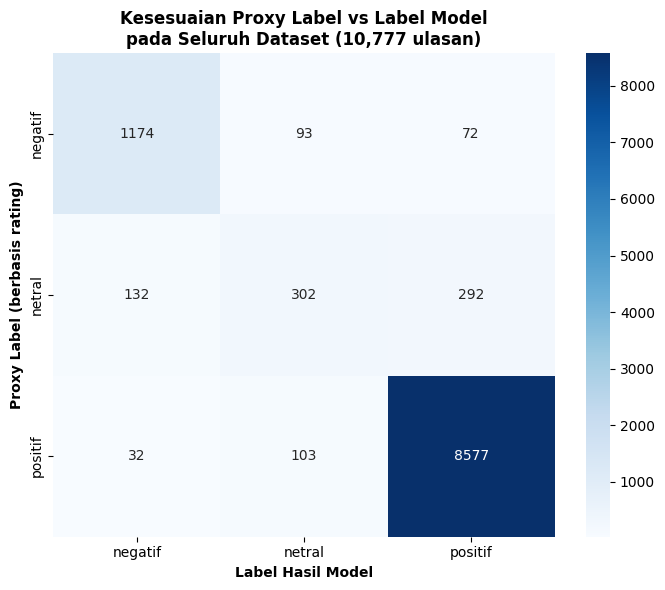

💾 Disimpan: kesesuaian_proxy_vs_model_dataset_penuh.png


In [ ]:
# Confusion matrix: proxy label vs label model (seluruh dataset)
cm_full = confusion_matrix(
    df_full["proxy_sentiment"],
    df_full["sentiment_label"],
    labels=LABEL_ORDER
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_full, annot=True, fmt="d",
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    cmap="Blues", cbar=True
)
plt.xlabel("Label Hasil Model", fontweight="bold")
plt.ylabel("Proxy Label (berbasis rating)", fontweight="bold")
plt.title(f"Kesesuaian Proxy Label vs Label Model\n"
          f"pada Seluruh Dataset ({len(df_full):,} ulasan)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("kesesuaian_proxy_vs_model_dataset_penuh.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Disimpan: kesesuaian_proxy_vs_model_dataset_penuh.png")

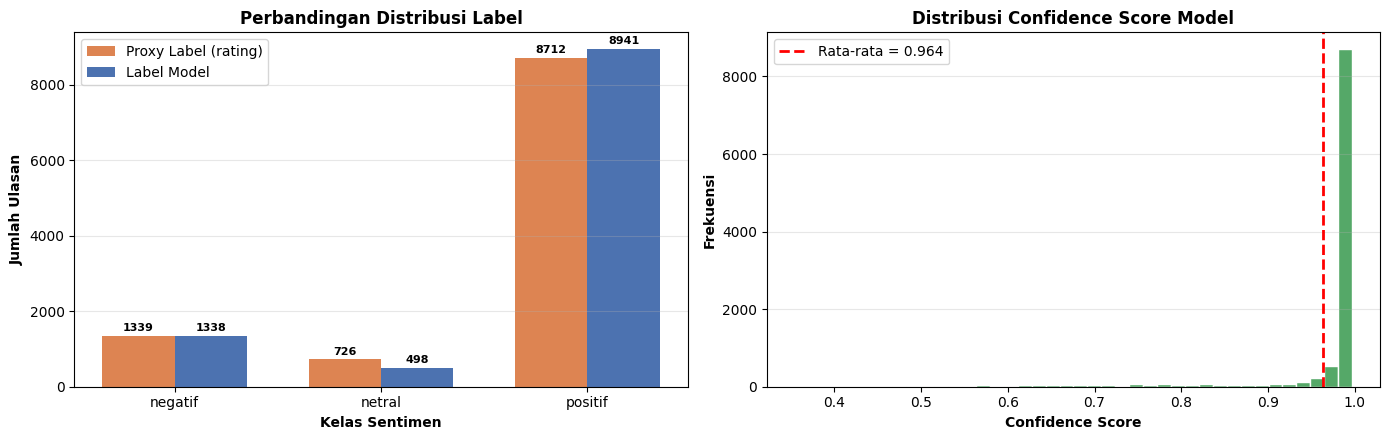

💾 Disimpan: distribusi_label_dan_confidence_dataset_akhir.png


In [ ]:
# Visualisasi distribusi label dan confidence score
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Kiri: perbandingan distribusi label
x = np.arange(len(LABEL_ORDER))
width = 0.35

b1 = axes[0].bar(x - width/2, dist_comparison["Proxy Label (rating)"], width,
                 label="Proxy Label (rating)", color="#DD8452")
b2 = axes[0].bar(x + width/2, dist_comparison["Label Model"], width,
                 label="Label Model", color="#4C72B0")

axes[0].set_ylabel("Jumlah Ulasan", fontweight="bold")
axes[0].set_xlabel("Kelas Sentimen", fontweight="bold")
axes[0].set_title("Perbandingan Distribusi Label", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABEL_ORDER)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bars in [b1, b2]:
    axes[0].bar_label(bars, fmt="%d", fontsize=8, fontweight="bold", padding=2)

# Kanan: distribusi confidence score
axes[1].hist(df_full["confidence_score"], bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(df_full["confidence_score"].mean(), color="red",
                linestyle="--", linewidth=2,
                label=f"Rata-rata = {df_full['confidence_score'].mean():.3f}")
axes[1].set_xlabel("Confidence Score", fontweight="bold")
axes[1].set_ylabel("Frekuensi", fontweight="bold")
axes[1].set_title("Distribusi Confidence Score Model", fontweight="bold")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("distribusi_label_dan_confidence_dataset_akhir.png", dpi=300, bbox_inches="tight")
plt.show()
print("💾 Disimpan: distribusi_label_dan_confidence_dataset_akhir.png")

In [ ]:
# Analisis confidence score per kelas dan per bahasa
print("=" * 70)
print("📊 RATA-RATA CONFIDENCE SCORE")
print("=" * 70)

conf_per_kelas = df_full.groupby("sentiment_label")["confidence_score"].agg(
    ["count", "mean", "median", "min", "max"]
).round(4)
conf_per_kelas = conf_per_kelas.reindex(LABEL_ORDER)
print("\n📊 Per kelas sentimen:")
display(conf_per_kelas)

conf_per_bahasa = df_full.groupby("language")["confidence_score"].agg(
    ["count", "mean", "median", "min", "max"]
).round(4)
print("\n📊 Per bahasa:")
display(conf_per_bahasa)

# Confidence pada prediksi yang sesuai vs tidak sesuai dengan proxy label
df_full["sesuai_proxy"] = df_full["proxy_sentiment"] == df_full["sentiment_label"]

conf_agreement = df_full.groupby("sesuai_proxy")["confidence_score"].agg(
    ["count", "mean", "median"]
).round(4)

# Penamaan indeks dilakukan secara aman (tidak mengasumsikan kedua grup ada)
conf_agreement.index = [
    "Sesuai proxy" if idx else "Tidak sesuai proxy"
    for idx in conf_agreement.index
]

print("\n📊 Berdasarkan kesesuaian dengan proxy label:")
display(conf_agreement)

print(f"\n💡 Catatan: confidence score yang lebih tinggi pada prediksi yang")
print(f"   sesuai dengan proxy label menunjukkan bahwa model cenderung lebih")
print(f"   yakin ketika prediksinya selaras dengan sinyal rating pengguna.")

📊 RATA-RATA CONFIDENCE SCORE

📊 Per kelas sentimen:


,count,mean,median,min,max
sentiment_label,,,,,
negatif,1338,0.9273,0.9786,0.4793,0.9941
netral,498,0.6808,0.6856,0.3544,0.8614
positif,8941,0.9847,0.9952,0.4182,0.9970



📊 Per bahasa:


,count,mean,median,min,max
language,,,,,
en,6980,0.9572,0.9944,0.4343,0.9969
es,250,0.9526,0.9940,0.4857,0.9967
id,3547,0.9767,0.9948,0.3544,0.9970



📊 Berdasarkan kesesuaian dengan proxy label:


,count,mean,median
Tidak sesuai proxy,724,0.8099,0.8324
Sesuai proxy,10053,0.9746,0.9949



💡 Catatan: confidence score yang lebih tinggi pada prediksi yang
   sesuai dengan proxy label menunjukkan bahwa model cenderung lebih
   yakin ketika prediksinya selaras dengan sinyal rating pengguna.


In [ ]:
# Contoh kasus ketidaksesuaian antara proxy label dan label model
print("=" * 70)
print("📋 CONTOH KASUS KETIDAKSESUAIAN PROXY LABEL vs LABEL MODEL")
print("=" * 70)

mismatch = df_full[~df_full["sesuai_proxy"]].copy()
mismatch = mismatch.sort_values("confidence_score", ascending=False)

print(f"\nTotal ketidaksesuaian: {len(mismatch):,} ulasan")
print(f"\n📋 5 contoh dengan confidence tertinggi:")
print("-" * 100)

for idx, row in mismatch.head(5).iterrows():
    print(f"Rating: {row['rating']} | Proxy: {row['proxy_sentiment']:<8} | "
          f"Model: {row['sentiment_label']:<8} | Confidence: {row['confidence_score']:.4f}")
    print(f"Bahasa: {row['language']}")
    print(f"Ulasan: {str(row[TEXT_COL])[:180]}...")
    print("-" * 100)

print(f"\n💡 Kasus-kasus ini mengilustrasikan keterbatasan proxy label berbasis")
print(f"   rating: rating pengguna tidak selalu selaras dengan sentimen yang")
print(f"   tersirat dalam teks ulasan.")

📋 CONTOH KASUS KETIDAKSESUAIAN PROXY LABEL vs LABEL MODEL

Total ketidaksesuaian: 724 ulasan

📋 5 contoh dengan confidence tertinggi:
----------------------------------------------------------------------------------------------------
Rating: 3 | Proxy: netral   | Model: positif  | Confidence: 0.9964
Bahasa: en
Ulasan: Perfect time. I might name like this my water johney with Saraswati. He decorate a boat for me with baloons. He is so gentle boat driver, we where always in safe but distance from ...
----------------------------------------------------------------------------------------------------
Rating: 3 | Proxy: netral   | Model: positif  | Confidence: 0.9963
Bahasa: id
Ulasan: Kolam yg indah dengan air kolam yg mengalir dari sumber mata air yg bs di minum..pemandangan alam yg masih asri pedesaan..air yg sejuk akan membuat badan segar dan pikiran jernih s...
----------------------------------------------------------------------------------------------------
Rating: 1 | Proxy: nega

## Section 18 — Ekspor Dataset Akhir Siap Publikasi

Dataset akhir yang telah dilabeli menggunakan model terbaik disusun
dengan struktur kolom yang rapi dan siap dipublikasikan sebagai
kontribusi penelitian.

**Struktur kolom dataset publikasi:**

| Kolom | Keterangan |
|-------|------------|
| `review_id` | Identitas unik setiap ulasan |
| `nama_tempat` | Nama attraction atau tempat wisata |
| `kabupaten`, `provinsi` | Informasi lokasi attraction |
| `rating` | Rating asli dari pengguna (1–5) |
| `review` | Teks ulasan asli sebelum praproses |
| `review_clean` | Teks ulasan hasil praproses |
| `language` | Bahasa hasil deteksi dan normalisasi (en/id/es) |
| `proxy_sentiment` | Label acuan berbasis rating (*distant supervision*) |
| `sentiment_label` | **Label sentimen hasil model terbaik** |
| `confidence_score` | Skor kepercayaan model terhadap prediksi |
| `sumber` | Platform asal data (TripAdvisor / Google Review) |

> **Catatan:** Kolom `user_id` **tidak disertakan** pada dataset publikasi
> demi menjaga privasi pengguna.

In [ ]:
# Susun struktur kolom dataset publikasi
KOLOM_PUBLIKASI = [
    "review_id",
    "nama_tempat",
    "kabupaten",
    "provinsi",
    "rating",
    "review",
    "review_clean",
    "language",
    "proxy_sentiment",
    "sentiment_label",
    "confidence_score",
    "sumber",
]

kolom_publikasi_ada = [c for c in KOLOM_PUBLIKASI if c in df_full.columns]
df_publikasi = df_full[kolom_publikasi_ada].copy()

# Urutkan berdasarkan review_id
df_publikasi = df_publikasi.sort_values("review_id").reset_index(drop=True)

print("✅ Dataset publikasi berhasil disusun")
print(f"   Jumlah baris : {len(df_publikasi):,}")
print(f"   Jumlah kolom : {len(df_publikasi.columns)}")
print(f"\n📋 Struktur kolom:")
for i, col in enumerate(df_publikasi.columns, 1):
    n_null = df_publikasi[col].isnull().sum()
    note = f"  ({n_null:,} null)" if n_null > 0 else ""
    print(f"   {i:>2}. {col}{note}")

print(f"\n🔒 Kolom 'user_id' tidak disertakan demi menjaga privasi pengguna.")

df_publikasi.head(3)

✅ Dataset publikasi berhasil disusun
   Jumlah baris : 10,777
   Jumlah kolom : 12

📋 Struktur kolom:
    1. review_id
    2. nama_tempat
    3. kabupaten  (1,306 null)
    4. provinsi
    5. rating
    6. review
    7. review_clean
    8. language
    9. proxy_sentiment
   10. sentiment_label
   11. confidence_score
   12. sumber

🔒 Kolom 'user_id' tidak disertakan demi menjaga privasi pengguna.


,review_id,nama_tempat,kabupaten,provinsi,rating,review,review_clean,language,proxy_sentiment,sentiment_label,confidence_score,sumber
0,1,Kebon Vintage Cars,Denpasar City,Bali,5,"Had a wonderful time at Kebon Vintage Cars, lo...","Had a wonderful time at Kebon Vintage Cars, lo...",en,positif,positif,0.9962,Google Review
1,2,Kebon Vintage Cars,Denpasar City,Bali,5,Was wonderful experience to visite kebon vinta...,Was wonderful experience to visite kebon vinta...,en,positif,positif,0.9967,Google Review
2,3,Kebon Vintage Cars,Denpasar City,Bali,5,Great selection of cars from private collectio...,Great selection of cars from private collectio...,en,positif,positif,0.9955,Google Review


In [ ]:
# Susun metadata / dataset card untuk publikasi
from datetime import datetime

metadata = pd.DataFrame([
    {"Atribut": "Nama Dataset",
     "Nilai": "Bali Attraction Reviews — Multilingual Sentiment Dataset"},
    {"Atribut": "Jumlah Ulasan",
     "Nilai": f"{len(df_publikasi):,}"},
    {"Atribut": "Jumlah Kolom",
     "Nilai": f"{len(df_publikasi.columns)}"},
    {"Atribut": "Sumber Data",
     "Nilai": "TripAdvisor dan Google Review"},
    {"Atribut": "Wilayah",
     "Nilai": "Provinsi Bali, Indonesia"},
    {"Atribut": "Jenis Destinasi",
     "Nilai": "Attraction (daya tarik wisata)"},
    {"Atribut": "Bahasa",
     "Nilai": "Bahasa Indonesia (id), Bahasa Inggris (en), Bahasa Spanyol (es)"},
    {"Atribut": "Rentang Waktu Ulasan",
     "Nilai": "2020–2025"},
    {"Atribut": "Kelas Sentimen",
     "Nilai": "positif, netral, negatif"},
    {"Atribut": "Metode Proxy Label",
     "Nilai": "Distant supervision berbasis rating (1–2 negatif, 3 netral, 4–5 positif)"},
    {"Atribut": "Model Pelabelan",
     "Nilai": BEST_MODEL_LABEL},
    {"Atribut": "Checkpoint Model",
     "Nilai": best_model_info["checkpoint"]},
    {"Atribut": "Macro F1-score Model",
     "Nilai": f"{best_row['macro_f1']:.2f}%"},
    {"Atribut": "Accuracy Model",
     "Nilai": f"{best_row['accuracy']:.2f}%"},
    {"Atribut": "Tingkat Kesesuaian Model vs Proxy",
     "Nilai": f"{agreement_pct:.2f}%"},
    {"Atribut": "Tanggal Pembuatan",
     "Nilai": datetime.now().strftime("%d %B %Y")},
    {"Atribut": "Catatan Penting",
     "Nilai": "Label sentimen merupakan hasil pelabelan otomatis, bukan anotasi manual manusia"},
])

print("=" * 70)
print("📋 METADATA DATASET (DATASET CARD)")
print("=" * 70)
display(metadata)

📋 METADATA DATASET (DATASET CARD)


,Atribut,Nilai
0,Nama Dataset,Bali Attraction Reviews — Multilingual Sentime...
1,Jumlah Ulasan,"10,777"
2,Jumlah Kolom,12
3,Sumber Data,TripAdvisor dan Google Review
4,Wilayah,"Provinsi Bali, Indonesia"
5,Jenis Destinasi,Attraction (daya tarik wisata)
6,Bahasa,"Bahasa Indonesia (id), Bahasa Inggris (en), Ba..."
7,Rentang Waktu Ulasan,2020–2025
8,Kelas Sentimen,"positif, netral, negatif"
9,Metode Proxy Label,Distant supervision berbasis rating (1–2 negat...


In [ ]:
# Susun statistik ringkasan dataset publikasi
statistik_bahasa = df_publikasi["language"].value_counts().reset_index()
statistik_bahasa.columns = ["Bahasa", "Jumlah"]
statistik_bahasa["Persentase"] = (
    statistik_bahasa["Jumlah"] / len(df_publikasi) * 100
).round(2)

statistik_sentimen = df_publikasi["sentiment_label"].value_counts().reset_index()
statistik_sentimen.columns = ["Sentimen", "Jumlah"]
statistik_sentimen["Persentase"] = (
    statistik_sentimen["Jumlah"] / len(df_publikasi) * 100
).round(2)

statistik_sumber = df_publikasi["sumber"].value_counts().reset_index()
statistik_sumber.columns = ["Sumber", "Jumlah"]
statistik_sumber["Persentase"] = (
    statistik_sumber["Jumlah"] / len(df_publikasi) * 100
).round(2)

# Crosstab bahasa × sentimen
crosstab_final = pd.crosstab(
    df_publikasi["language"],
    df_publikasi["sentiment_label"],
    margins=True, margins_name="Total"
).reset_index()

print("📊 Statistik Bahasa:")
display(statistik_bahasa)
print("\n📊 Statistik Sentimen (label model):")
display(statistik_sentimen)
print("\n📊 Statistik Sumber:")
display(statistik_sumber)
print("\n📊 Crosstab Bahasa × Sentimen:")
display(crosstab_final)

📊 Statistik Bahasa:


,Bahasa,Jumlah,Persentase
0,en,6980,64.77
1,id,3547,32.91
2,es,250,2.32



📊 Statistik Sentimen (label model):


,Sentimen,Jumlah,Persentase
0,positif,8941,82.96
1,negatif,1338,12.42
2,netral,498,4.62



📊 Statistik Sumber:


,Sumber,Jumlah,Persentase
0,Google Review,6038,56.03
1,Tripadvisor,4739,43.97



📊 Crosstab Bahasa × Sentimen:


sentiment_label,language,negatif,netral,positif,Total
0,en,1021,411,5548,6980
1,es,46,16,188,250
2,id,271,71,3205,3547
3,Total,1338,498,8941,10777


In [ ]:
# Ekspor dataset publikasi
NAMA_DATASET = "Dataset_Ulasan_Attraction_Bali_Berlabel_Sentimen"

# 1. Ekspor sebagai CSV (format umum untuk publikasi dataset)
df_publikasi.to_csv(f"{NAMA_DATASET}.csv", index=False, encoding="utf-8-sig")

# 2. Ekspor sebagai Excel multi-sheet (dataset + metadata + statistik)
with pd.ExcelWriter(f"{NAMA_DATASET}.xlsx") as writer:
    df_publikasi.to_excel(writer, sheet_name="Dataset", index=False)
    metadata.to_excel(writer, sheet_name="Metadata", index=False)
    statistik_bahasa.to_excel(writer, sheet_name="Statistik_Bahasa", index=False)
    statistik_sentimen.to_excel(writer, sheet_name="Statistik_Sentimen", index=False)
    statistik_sumber.to_excel(writer, sheet_name="Statistik_Sumber", index=False)
    crosstab_final.to_excel(writer, sheet_name="Crosstab_Bahasa_Sentimen", index=False)
    dist_comparison.reset_index().to_excel(
        writer, sheet_name="Proxy_vs_Model", index=False)

# 3. Ekspor versi lengkap dengan seluruh kolom (untuk dokumentasi internal)
df_full.drop(columns=["sesuai_proxy"], errors="ignore").to_excel(
    f"{NAMA_DATASET}_Lengkap.xlsx", index=False)

print("=" * 70)
print("✅ DATASET AKHIR BERHASIL DIEKSPOR")
print("=" * 70)
print(f"\n📁 Berkas yang dihasilkan:")
print(f"   1. {NAMA_DATASET}.csv")
print(f"      → Format CSV siap publikasi ({len(df_publikasi):,} baris)")
print(f"   2. {NAMA_DATASET}.xlsx")
print(f"      → Format Excel dengan metadata dan statistik")
print(f"   3. {NAMA_DATASET}_Lengkap.xlsx")
print(f"      → Versi lengkap dengan seluruh kolom (dokumentasi internal)")

✅ DATASET AKHIR BERHASIL DIEKSPOR

📁 Berkas yang dihasilkan:
   1. Dataset_Ulasan_Attraction_Bali_Berlabel_Sentimen.csv
      → Format CSV siap publikasi (10,777 baris)
   2. Dataset_Ulasan_Attraction_Bali_Berlabel_Sentimen.xlsx
      → Format Excel dengan metadata dan statistik
   3. Dataset_Ulasan_Attraction_Bali_Berlabel_Sentimen_Lengkap.xlsx
      → Versi lengkap dengan seluruh kolom (dokumentasi internal)


## Section 19 — Ringkasan Akhir Keseluruhan Proses

Rekapitulasi menyeluruh dari kedua bagian notebook ini:
evaluasi komparatif model dan pelabelan dataset akhir.

In [ ]:
# Ringkasan akhir keseluruhan
print("=" * 72)
print("🎉 SELURUH PROSES NOTEBOOK 03 SELESAI!")
print("=" * 72)

print(f"\n{'─'*72}")
print(f"BAGIAN I — EVALUASI KOMPARATIF MODEL")
print(f"{'─'*72}")
print(f"   Jumlah model dievaluasi : {len(main_results_percent_sorted)}")
print(f"   Data test set           : {int(best_row['n_data']):,} ulasan")
print(f"   Metrik utama            : Macro F1-score")
print(f"\n   Peringkat model:")
for _, row in main_results_percent_sorted.iterrows():
    marker = "🏆" if row["Peringkat"] == 1 else "  "
    print(f"   {marker} {int(row['Peringkat'])}. {row['model']:<30} "
          f"Macro F1 = {row['macro_f1']:>6.2f}%  |  Acc = {row['accuracy']:>6.2f}%")

print(f"\n{'─'*72}")
print(f"BAGIAN II — PELABELAN DATASET AKHIR")
print(f"{'─'*72}")
print(f"   Model pelabelan         : {BEST_MODEL_LABEL}")
print(f"   Total data dilabeli     : {len(df_publikasi):,} ulasan")
print(f"   Rata-rata confidence    : {df_full['confidence_score'].mean():.4f}")
print(f"   Kesesuaian dengan proxy : {agreement_pct:.2f}%")
print(f"\n   Distribusi label akhir:")
for sent in LABEL_ORDER:
    count = (df_publikasi["sentiment_label"] == sent).sum()
    print(f"      {sent:<10}: {count:>6,} ({count/len(df_publikasi)*100:>5.2f}%)")

print(f"\n{'─'*72}")
print(f"LUARAN PENELITIAN")
print(f"{'─'*72}")
print(f"   📊 Hasil_Evaluasi_Model.xlsx")
print(f"      → Seluruh hasil evaluasi komparatif lima model")
print(f"   📁 {NAMA_DATASET}.csv / .xlsx")
print(f"      → Dataset akhir berlabel sentimen siap publikasi")
print(f"   🖼️  Berkas visualisasi (.png)")
print(f"      → Confusion matrix, perbandingan model, dan distribusi label")

print(f"\n{'='*72}")
print(f"✅ Dataset ulasan attraction Bali berlabel sentimen telah dihasilkan")
print(f"   sebagai kontribusi utama penelitian ini.")
print(f"{'='*72}")

🎉 SELURUH PROSES NOTEBOOK 03 SELESAI!

────────────────────────────────────────────────────────────────────────
BAGIAN I — EVALUASI KOMPARATIF MODEL
────────────────────────────────────────────────────────────────────────
   Jumlah model dievaluasi : 5
   Data test set           : 1,617 ulasan
   Metrik utama            : Macro F1-score

   Peringkat model:
   🏆 1. GPT prompt-based zero-shot     Macro F1 =  70.88%  |  Acc =  83.67%
      2. XLM-RoBERTa fine-tuned         Macro F1 =  70.74%  |  Acc =  89.98%
      3. mBERT fine-tuned               Macro F1 =  63.82%  |  Acc =  88.13%
      4. XLM-RoBERTa zero-shot          Macro F1 =  58.85%  |  Acc =  87.94%
      5. mBERT-XNLI zero-shot           Macro F1 =  46.97%  |  Acc =  79.47%

────────────────────────────────────────────────────────────────────────
BAGIAN II — PELABELAN DATASET AKHIR
────────────────────────────────────────────────────────────────────────
   Model pelabelan         : XLM-RoBERTa fine-tuned
   Total data dilabel

In [ ]:

from google.colab import files

# # Hasil evaluasi model
files.download("Hasil_Evaluasi_Model.xlsx")
files.download("Test_Set_Dengan_Prediksi_Semua_Model.xlsx")

# # Dataset akhir siap publikasi
files.download(f"{NAMA_DATASET}.csv")
files.download(f"{NAMA_DATASET}.xlsx")
files.download(f"{NAMA_DATASET}_Lengkap.xlsx")
# # Visualisasi
files.download("perbandingan_macro_f1_semua_model.png")
files.download("perbandingan_accuracy_semua_model.png")
files.download("perbandingan_accuracy_vs_macrof1.png")
files.download("perbandingan_f1_per_kelas.png")
files.download("perbandingan_macro_f1_per_bahasa.png")
files.download("kesesuaian_proxy_vs_model_dataset_penuh.png")
files.download("distribusi_label_dan_confidence_dataset_akhir.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>